# Tutorial 2 — Point Clouds on $S^2$ and $S^3$

**MM845 — Tópicos de Geometria III: AI for Geometry**
Paired with **Lecture 2: Mathematical Foundations of Machine Learning**

---

Lecture 2 stated the thesis

$$\text{learning} \;=\; \text{approximation theory} \;+\; \text{optimisation} \;+\; \text{statistics},$$

and claimed that each ingredient carries geometric content. This notebook makes
that claim concrete on the simplest interesting manifolds available to us: the
round spheres $S^2 \subset \mathbb{R}^3$ and $S^3 \subset \mathbb{R}^4$.

Spheres are the right laboratory precisely because **we know the answers**. Every
quantity a machine-learning method will estimate — the intrinsic dimension, the
uniform measure, the geodesic distance, the eigenfunctions of the Laplacian, the
symmetry group — is available to us in closed form. When a method recovers it, we
can *prove* it did; when it fails, we can see exactly where. This is a luxury real
data never offers, and it is the reason the whole course works with geometric
datasets.

### What you will do

| § | Topic | Lecture 2 connection |
|---|---|---|
| 1 | Sampling $S^1$, $S^2$: what "uniform" means, and how to get it wrong | data generation, measure $\mu$ |
| 2 | Quasi-uniform point sets, subsampling, triangulation | representation choices |
| 3 | Chordal vs geodesic distance; the distribution of distances | metric geometry of the data |
| 4 | $SO(3)$ acting on $S^2$: group actions, invariance, orbit-aware splits | slide 11, "split by orbit, not by sample" |
| 5 | $S^3$, unit quaternions, and the Hopf fibration | visualising what you cannot draw |
| 6 | Concentration of measure and the curse of dimensionality | slide 9 |
| 7 | The manifold hypothesis: recovering $\dim = 2$ from $\mathbb{R}^{100}$ | slide 8 |
| 8 | Supervised learning on $S^2$ as energy minimisation; the U-curve | slides 4, 6, 7 |

Exercises appear throughout, marked **Exercise $n$**. They are the point of the
tutorial — the prose exists to set them up. Hints are given; the solutions are
discussed in the session.

### Before you start

You need the `aigeo` environment from **Tutorial 1**, and the kernel selected at
the top right of this window should say so. Check with the cell below; if it
fails, revisit [Tutorial 1 §9](../tutorial_01/README.md#9-troubleshooting).

In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)
from scipy.spatial import ConvexHull, cKDTree

print("python     ", sys.version.split()[0])
print("numpy      ", np.__version__)
print("matplotlib ", plt.matplotlib.__version__)

python      3.12.11
numpy       2.5.2
matplotlib  3.11.1


### Reproducibility: fix the seed once, at the top

Lecture 1 listed three ingredients of a reproducible computation: code, environment,
and randomness. The third is handled here. We create one explicit random
*generator* object and pass it around, rather than calling `np.random.seed`
globally — this makes it visible in every function signature exactly which
computations are stochastic.

In [3]:
SEED = 20260805
rng = np.random.default_rng(SEED)

# --- course palette (matches the lecture slides) --------------------------------
GEO_DARK, GEO_TEAL, GEO_RUST = "#103158", "#006c86", "#b2461e"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.prop_cycle": plt.cycler(color=[GEO_DARK, GEO_TEAL, GEO_RUST,
                                         "#6a8caf", "#4c9a2a", "#7d3c98"]),
})

# For an interactive, rotatable 3-D view instead of static pictures:
#   pip install ipympl     and then uncomment the next line
# %matplotlib widget

Two plotting helpers we will reuse throughout. Reading them is optional; the point
of isolating them in a function, as Lecture 1 urged, is that the *interesting*
cells below then contain only mathematics.

In [4]:
def sphere_ax(fig, pos, title="", elev=22, azim=35, lim=1.05):
    """Create a 3-D axis with equal aspect, sized for the unit sphere."""
    ax = fig.add_subplot(pos, projection="3d")
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_title(title)
    ax.grid(False)
    return ax


def draw_wire_sphere(ax, color="0.6", alpha=0.15, n=24):
    """Faint wireframe of the unit sphere, to give the point cloud a reference."""
    u = np.linspace(0, 2 * np.pi, 2 * n)
    v = np.linspace(0, np.pi, n)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color=color, alpha=alpha,
                      linewidth=0.4, rstride=2, cstride=2)
    return ax

---
## 1. Sampling: what does "uniform on $S^2$" mean?

Lecture 2 began from a measure space $(X, \mu)$ and i.i.d. samples from $\mu$. Our
first task is therefore to *produce* those samples — and the choice of $\mu$ is
already a mathematical decision, not a technicality.

For a sphere the canonical choice is the unique probability measure invariant
under the isometry group $O(n)$; equivalently, normalised Riemannian volume. Any
sampling scheme must be checked against that definition, because the obvious
scheme is wrong.

### 1.1 The naive scheme, and why it fails

Parametrise $S^2$ by spherical coordinates,

$$\Phi(\theta,\varphi) = (\sin\varphi\cos\theta,\; \sin\varphi\sin\theta,\; \cos\varphi),
\qquad \theta \in [0,2\pi),\; \varphi \in [0,\pi].$$

It is tempting to draw $\theta$ and $\varphi$ uniformly from their ranges. But the
pullback of the area form is

$$\Phi^*(\mathrm{d}A) = \sin\varphi \, \mathrm{d}\varphi \wedge \mathrm{d}\theta \;\neq\; \mathrm{d}\varphi \wedge \mathrm{d}\theta ,$$

so uniform $(\theta,\varphi)$ over-weights the poles, where the Jacobian factor
$\sin\varphi$ vanishes. This is the same fact that makes a Mercator map of the
Earth exaggerate Greenland.

### 1.2 Two schemes that work

**Gaussian normalisation (Muller's method).** If $x \sim \mathcal{N}(0, I_n)$ then
its density $\propto e^{-\|x\|^2/2}$ is rotation-invariant, hence so is the law of
$x/\|x\|$. This works in *every* dimension — we will use it for $S^3$ too.

**Archimedes' theorem.** The projection $S^2 \to [-1,1]$, $(x,y,z) \mapsto z$, is
measure-preserving up to the constant $2\pi$: the area of a spherical zone depends
only on its height. So drawing $z \sim U[-1,1]$ and $\theta \sim U[0,2\pi)$ gives
a uniform point. This is special to $S^2$.

In [5]:
def sample_sphere(n_points, dim, rng):
    """n_points uniform samples on S^{dim-1} = unit sphere in R^dim (Muller)."""
    x = rng.normal(size=(n_points, dim))
    return x / np.linalg.norm(x, axis=1, keepdims=True)


def sample_naive_angles(n_points, rng):
    """WRONG for S^2: uniform in the coordinate rectangle, not in area."""
    theta = rng.uniform(0, 2 * np.pi, n_points)   # azimuth
    phi = rng.uniform(0, np.pi, n_points)         # polar angle
    return np.stack([np.sin(phi) * np.cos(theta),
                     np.sin(phi) * np.sin(theta),
                     np.cos(phi)], axis=1)


def sample_archimedes(n_points, rng):
    """Correct for S^2: uniform height z, uniform azimuth."""
    z = rng.uniform(-1, 1, n_points)
    theta = rng.uniform(0, 2 * np.pi, n_points)
    r = np.sqrt(1 - z**2)
    return np.stack([r * np.cos(theta), r * np.sin(theta), z], axis=1)


N = 2000
X_gauss = sample_sphere(N, 3, rng)
X_naive = sample_naive_angles(N, rng)
X_arch = sample_archimedes(N, rng)

# Sanity check first, plot second: every point must have unit norm.
for name, X in [("gaussian", X_gauss), ("naive", X_naive), ("archimedes", X_arch)]:
    assert np.allclose(np.linalg.norm(X, axis=1), 1.0), name
print("all three samples lie on the unit sphere")

all three samples lie on the unit sphere


Now look at them. The bias is visible without any statistics — the naive cloud has
conspicuous tufts at the poles.

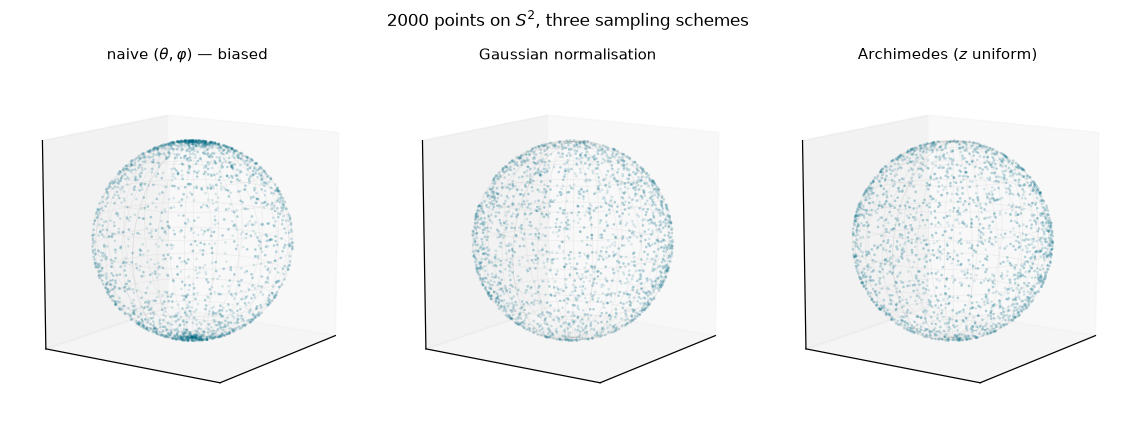

In [6]:
fig = plt.figure(figsize=(10.5, 3.8))
for k, (name, X) in enumerate([("naive $(\\theta,\\varphi)$ — biased", X_naive),
                               ("Gaussian normalisation", X_gauss),
                               ("Archimedes ($z$ uniform)", X_arch)]):
    ax = sphere_ax(fig, 131 + k, name, elev=12)
    draw_wire_sphere(ax)
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=3, c=GEO_TEAL, alpha=0.55, lw=0)
fig.suptitle("2000 points on $S^2$, three sampling schemes", y=1.02)
plt.tight_layout(); plt.show()

### 1.3 Detecting the bias quantitatively

Eyeballing a picture is not a test. Archimedes' theorem gives us one: for a
*uniform* point on $S^2$, the coordinate $z$ is exactly uniform on $[-1,1]$. So
histogram $z$ and compare against the flat density $\tfrac12$.

This is the pattern to internalise, and it recurs for the rest of the course:
**find a scalar statistic whose exact distribution you know, and check it.**

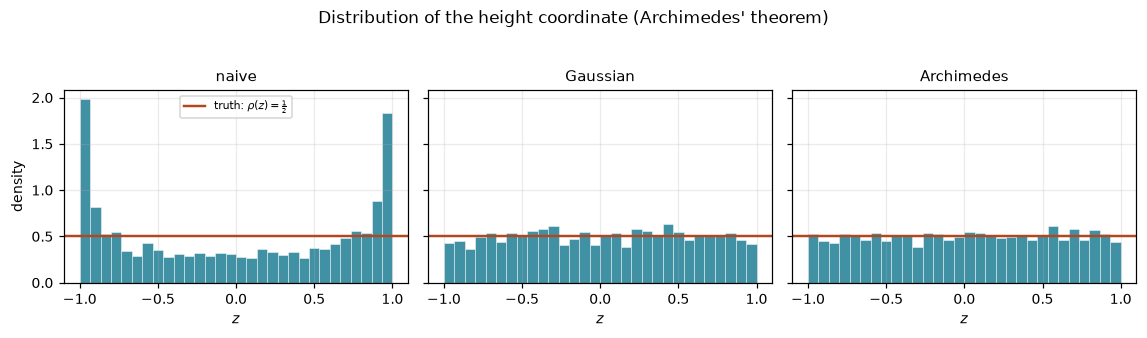

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.9), sharey=True)
for ax, (name, X) in zip(axes, [("naive", X_naive),
                                ("Gaussian", X_gauss),
                                ("Archimedes", X_arch)]):
    ax.hist(X[:, 2], bins=30, range=(-1, 1), density=True,
            color=GEO_TEAL, alpha=0.75, edgecolor="white", lw=0.4)
    ax.axhline(0.5, color=GEO_RUST, lw=1.6, label=r"truth: $\rho(z)=\frac{1}{2}$")
    ax.set_title(name); ax.set_xlabel("$z$")
axes[0].set_ylabel("density"); axes[0].legend(fontsize=7)
fig.suptitle("Distribution of the height coordinate (Archimedes' theorem)", y=1.04)
plt.tight_layout(); plt.show()

> **Exercise 1 — a second, independent test.**
> The $z$-histogram checks the marginal in one direction only; a scheme could pass
> it and still be non-uniform in $\theta$.
>
> (a) Choose a fixed unit vector $u$ and histogram $\langle X_i, u \rangle$. What
> must the answer be, and why does taking a *random* $u$ make the test stronger?
>
> (b) Estimate the area of the spherical cap $\{z > 0.8\}$ by the fraction of
> sample points inside it, for each of the three schemes. Compare with the exact
> value $\tfrac{1-0.8}{2} = 0.1$ and report the Monte-Carlo error $\sim 1/\sqrt N$.
>
> (c) The naive scheme is *correct* for $S^1$ with uniform $\theta$. Why? At which
> step of §1.1 does the argument for $S^2$ break down, and what happens on $S^{n-1}$
> for $n \geq 4$?

exact area fraction of cap z>0.8 : 0.1000
  naive       0.2175
  gaussian    0.0945
  archimedes  0.1020
[ 0.02644777 -0.7023125  -0.7113773 ]


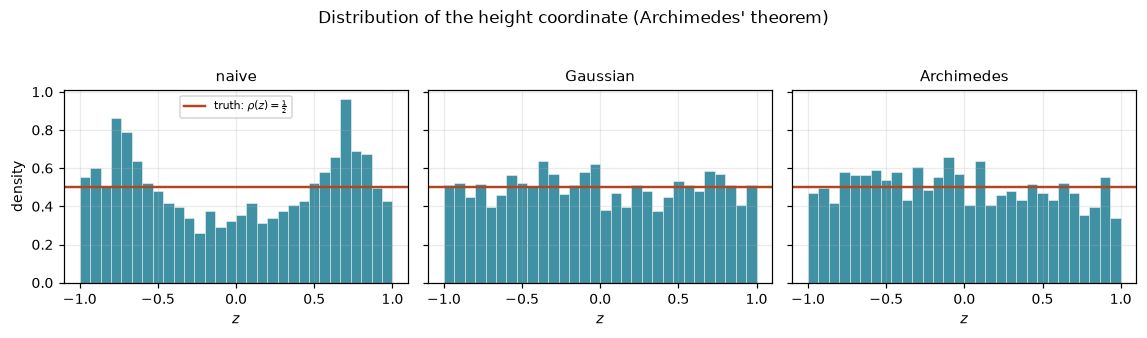

In [8]:
# --- Exercise 1: scaffold ------------------------------------------------------
u = sample_sphere(1, 3, rng)[0]          # a random direction

def cap_fraction(X, height):
    """Fraction of the sample lying in the cap {z > height}."""
    return np.mean(X[:, 2] > height)

print(f"exact area fraction of cap z>0.8 : {(1 - 0.8) / 2:.4f}")
for name, X in [("naive", X_naive), ("gaussian", X_gauss), ("archimedes", X_arch)]:
    print(f"  {name:11s} {cap_fraction(X, 0.8):.4f}")

# your turn: histogram X @ u for each scheme, and overlay the exact density

print(u)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.9), sharey=True)
for ax, (name, X) in zip(axes, [("naive", X_naive),
                                ("Gaussian", X_gauss),
                                ("Archimedes", X_arch)]):
    ax.hist(X @ u, bins=30, range=(-1, 1), density=True,
            color=GEO_TEAL, alpha=0.75, edgecolor="white", lw=0.4)
    ax.axhline(0.5, color=GEO_RUST, lw=1.6, label=r"truth: $\rho(z)=\frac{1}{2}$")
    ax.set_title(name); ax.set_xlabel("$z$")
axes[0].set_ylabel("density"); axes[0].legend(fontsize=7)
fig.suptitle("Distribution of the height coordinate (Archimedes' theorem)", y=1.04)
plt.tight_layout(); plt.show()

> **Exercise 2 — $S^1$, and the failure of the obvious generalisation.**
> Write `sample_circle_naive(n, rng)` using uniform $\theta$, and verify it is
> uniform. Then attempt the direct analogue of Archimedes on $S^3$: draw the last
> coordinate uniformly on $[-1,1]$ and the remaining three uniformly on a sphere of
> the matching radius. Test the result against `sample_sphere(n, 4, rng)` using the
> statistic from Exercise 1(a). What is the true density of a single coordinate of a
> uniform point on $S^{n-1}$? (You will derive it in §6 — attempt it first.)

(a) S^1 : KS two-sample p-value, naive vs Muller = 0.232   (no evidence of a difference)
    E[<X,u>^2] : naive 0.5015  Muller 0.5003  exact 0.5000

(b) S^3 : KS two-sample p-values against a Muller sample
      along e4 : p = 5.31e-310
      along e1 : p = 1.29e-72
      random u : p = 1.40e-51

    second moments E[x_i^2], which must equal 1/n = 0.2500 for every i:
      naive-S^3 : [0.2214 0.2218 0.2233 0.3334]
      Muller    : [0.2497 0.2499 0.2503 0.2501]
    the naive scheme gives E[x4^2] = 1/3 = 0.3333 and E[x1^2] = 2/9 = 0.2222 exactly:
      x4 ~ U[-1,1] has variance 1/3, and x1 = sqrt(1-x4^2) * w1 with
      w1 ~ U[-1,1] by Archimedes on S^2, so E[x1^2] = (1 - 1/3)(1/3) = 2/9.

    the decisive symptom: the answer DEPENDS on the direction u.
      var<X,e4> = 0.3334  but  var<X,e1> = 0.2214;  a uniform sample cannot tell any two u apart.


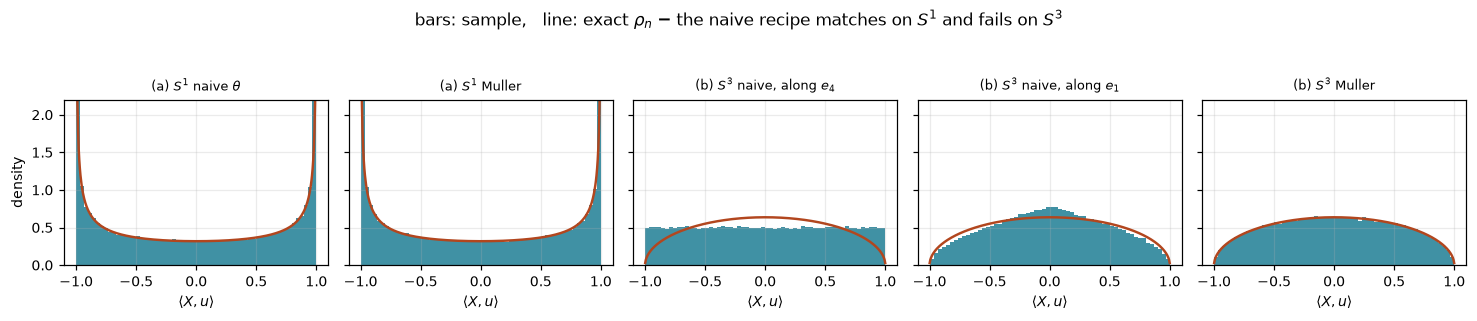

(c) rho_n(t) = c_n (1 - t^2)^{(n-3)/2}.  The naive 'uniform last coordinate'
    recipe is correct exactly when the exponent vanishes, i.e. only for n = 3.
      n =  2 :  exponent -0.5   arcsine  -- mass at the poles
      n =  3 :  exponent +0.0   uniform  -- Archimedes, the one lucky dimension
      n =  4 :  exponent +0.5   semicircle -- mass at the equator
      n = 10 :  exponent +3.5   sharply peaked at 0


In [9]:
# --- Exercise 2 -----------------------------------------------------------------
# (a) sample_circle_naive: uniform theta IS correct on S^1
# (b) the same recipe on S^3 is NOT correct
# (c) the density rho_n, and why n = 3 is the only dimension where the trick works
from scipy.special import gammaln
from scipy.stats import ks_2samp


def coord_density(t, n):
    """Exact density of ONE coordinate of a uniform point on S^{n-1}.

    Identical to `marginal_density` in section 6; repeated because this cell has
    to run before that one.  Derived in the notes below.
    """
    logc = gammaln(n / 2) - 0.5 * np.log(np.pi) - gammaln((n - 1) / 2)
    return np.exp(logc) * np.maximum(0.0, 1 - t**2) ** ((n - 3) / 2)


# ---- (a) on S^1 the naive scheme is right --------------------------------------
def sample_circle_naive(n_points, rng):
    """Uniform angle -> uniform on S^1.  Unlike its S^2 analogue, this one is right:
    arc length on the circle IS d(theta), so uniform theta is uniform measure."""
    theta = rng.uniform(0, 2 * np.pi, n_points)
    return np.stack([np.cos(theta), np.sin(theta)], axis=1)


M = 200_000
C_naive = sample_circle_naive(M, rng)
C_gauss = sample_sphere(M, 2, rng)
u2 = sample_sphere(1, 2, rng)[0]              # a random test direction, as in Ex 1(a)

print(f"(a) S^1 : KS two-sample p-value, naive vs Muller = "
      f"{ks_2samp(C_naive @ u2, C_gauss @ u2).pvalue:.3f}   (no evidence of a difference)")
print(f"    E[<X,u>^2] : naive {np.mean((C_naive @ u2)**2):.4f}  "
      f"Muller {np.mean((C_gauss @ u2)**2):.4f}  exact 0.5000")


# ---- (b) the same recipe on S^3 is wrong ---------------------------------------
def sample_archimedes_s3(n_points, rng):
    """The obvious generalisation: last coordinate uniform on [-1,1], the other three
    uniform on the sphere of the matching radius.  WRONG -- see the numbers below."""
    x4 = rng.uniform(-1, 1, n_points)
    r = np.sqrt(1 - x4**2)
    w = sample_sphere(n_points, 3, rng)
    return np.concatenate([r[:, None] * w, x4[:, None]], axis=1)


Q_arch = sample_archimedes_s3(M, rng)
Q_true = sample_sphere(M, 4, rng)
assert np.allclose(np.linalg.norm(Q_arch, axis=1), 1.0)   # it IS on the sphere ...

e1, e4 = np.eye(4)[0], np.eye(4)[3]
u4 = sample_sphere(1, 4, rng)[0]

print("\n(b) S^3 : KS two-sample p-values against a Muller sample")
for name, u in [("along e4", e4), ("along e1", e1), ("random u", u4)]:
    print(f"      {name} : p = {ks_2samp(Q_arch @ u, Q_true @ u).pvalue:.2e}")

print("\n    second moments E[x_i^2], which must equal 1/n = 0.2500 for every i:")
print("      naive-S^3 :", np.round((Q_arch**2).mean(axis=0), 4))
print("      Muller    :", np.round((Q_true**2).mean(axis=0), 4))
print(f"    the naive scheme gives E[x4^2] = 1/3 = {1/3:.4f} and "
      f"E[x1^2] = 2/9 = {2/9:.4f} exactly:")
print("      x4 ~ U[-1,1] has variance 1/3, and x1 = sqrt(1-x4^2) * w1 with")
print("      w1 ~ U[-1,1] by Archimedes on S^2, so E[x1^2] = (1 - 1/3)(1/3) = 2/9.")
print(f"\n    the decisive symptom: the answer DEPENDS on the direction u.")
print(f"      var<X,e4> = {np.var(Q_arch @ e4):.4f}  but  var<X,e1> = "
      f"{np.var(Q_arch @ e1):.4f};  a uniform sample cannot tell any two u apart.")

fig, axes = plt.subplots(1, 5, figsize=(13.5, 2.7), sharey=True)
t = np.linspace(-0.999, 0.999, 400)           # open interval: rho_2 blows up at +-1
for ax, (title, vals, n) in zip(axes, [
        (r"(a) $S^1$ naive $\theta$", C_naive @ u2, 2),
        (r"(a) $S^1$ Muller", C_gauss @ u2, 2),
        (r"(b) $S^3$ naive, along $e_4$", Q_arch @ e4, 4),
        (r"(b) $S^3$ naive, along $e_1$", Q_arch @ e1, 4),
        (r"(b) $S^3$ Muller", Q_true @ u4, 4)]):
    ax.hist(vals, bins=60, range=(-1, 1), density=True,
            color=GEO_TEAL, alpha=0.75, edgecolor="none")
    ax.plot(t, coord_density(t, n), color=GEO_RUST, lw=1.6)
    ax.set_title(title, fontsize=8.5); ax.set_xlabel(r"$\langle X, u\rangle$")
axes[0].set_ylabel("density"); axes[0].set_ylim(0, 2.2)
fig.suptitle(r"bars: sample,   line: exact $\rho_n$ "
             r"$-$ the naive recipe matches on $S^1$ and fails on $S^3$", y=1.06)
plt.tight_layout(); plt.show()


# ---- (c) the density, and the exponent that decides everything ------------------
print("(c) rho_n(t) = c_n (1 - t^2)^{(n-3)/2}.  The naive 'uniform last coordinate'")
print("    recipe is correct exactly when the exponent vanishes, i.e. only for n = 3.")
for n, shape in [(2, "arcsine  -- mass at the poles"),
                 (3, "uniform  -- Archimedes, the one lucky dimension"),
                 (4, "semicircle -- mass at the equator"),
                 (10, "sharply peaked at 0")]:
    print(f"      n = {n:2d} :  exponent {(n - 3) / 2:+.1f}   {shape}")


**Exercise 2 — notes.**

**(a)** On $S^1$ the naive scheme is correct, and for a reason that does not
generalise: arc length *is* $d\theta$. The uniform measure and the pushforward of
$\text{Unif}[0,2\pi)$ are the same measure, so there is nothing to get wrong. The
$S^2$ failure of §1.1 came from writing $dA = \sin\phi \, d\phi \, d\theta$ and then
sampling $\phi$ as though the $\sin\phi$ were not there; on $S^1$ there is no such
factor.

**(b)** The generalisation fails. Slice $S^{n-1}$ by the last coordinate,
$x = \big(\sqrt{1-t^2}\,\omega,\; t\big)$ with $\omega \in S^{n-2}$. Two competing
factors appear in the area element:

$$dA \;=\; \underbrace{(1-t^2)^{\frac{n-2}{2}}}_{\text{the slice sphere has radius }\sqrt{1-t^2}} \cdot \underbrace{(1-t^2)^{-\frac12}}_{\substack{\text{meridian arc length:}\\ ds \,=\, dt/\sqrt{1-t^2}}} \; dt \, d\omega \;=\; (1-t^2)^{\frac{n-3}{2}} \, dt \, d\omega .$$

The first factor pushes mass towards the equator, the second towards the poles.
**They cancel exactly when $n - 2 = 1$** — that is Archimedes' hat-box theorem, and
it is a coincidence of dimension $3$, not a principle. For $n = 4$ the slice
$2$-spheres shrink faster than the meridian stretches, so the true density of $x_4$
is a semicircle, while the naive recipe forces it flat.

Note what the numerics show: the scheme fails *along $e_1$ too*, in directions it
never touched. Its real defect is that it is not $SO(4)$-invariant — the distribution
of $\langle X, u\rangle$ depends on $u$, and invariance is the *definition* of uniform.
That is the test to run, and it is why Exercise 1(a) asked for a **random** $u$.

**(c)** Normalising by the Beta integral
$\int_{-1}^{1}(1-t^2)^{\frac{n-3}{2}}dt = B\big(\tfrac12, \tfrac{n-1}{2}\big)$,

$$\rho_n(t) \;=\; \frac{\Gamma(n/2)}{\sqrt{\pi}\,\Gamma\!\big(\frac{n-1}{2}\big)}\,\big(1-t^2\big)^{\frac{n-3}{2}}, \qquad t \in [-1,1],$$

which is exactly `marginal_density` in §6. The exponent $\tfrac{n-3}{2}$ tells the
whole story: negative for $n=2$ (arcsine, mass at the poles), zero for $n=3$
(uniform), positive thereafter. As $n$ grows it concentrates at $t = 0$ like a
Gaussian of width $1/\sqrt{n}$ — which is §6's concentration of measure, already
visible here.


---
## 2. Structured point sets: quasi-uniform, subsampled, triangulated

Random samples are the right model for *data*, but they are a poor way to *cover* a
manifold: independent points clump, leaving holes of size $\sim \sqrt{\log N / N}$.
When the point cloud is a numerical discretisation rather than a dataset — a
quadrature rule, a set of collocation points for a PINN in Lecture 12 — we want
something more even.

### 2.1 The Fibonacci lattice

Place points at heights $z_i = 1 - \frac{2i+1}{N}$ (equally spaced, by Archimedes)
and advance the azimuth by the golden angle $2\pi/\phi$, $\phi = \frac{1+\sqrt5}{2}$,
at each step. Because $\phi$ is the irrational number worst approximable by
rationals, the azimuths never come close to repeating, and the points spiral into a
remarkably even cover.

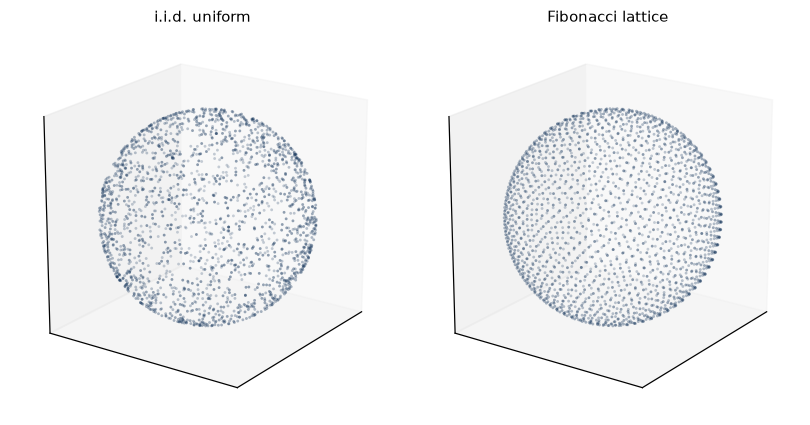

In [10]:
GOLDEN = (1 + 5**0.5) / 2


def fibonacci_sphere(n_points):
    """Deterministic quasi-uniform point set on S^2."""
    i = np.arange(n_points)
    z = 1 - 2 * (i + 0.5) / n_points
    r = np.sqrt(np.maximum(0.0, 1 - z**2))
    theta = 2 * np.pi * i / GOLDEN
    return np.stack([r * np.cos(theta), r * np.sin(theta), z], axis=1)


X_fib = fibonacci_sphere(N)

fig = plt.figure(figsize=(7.5, 3.8))
for k, (name, X) in enumerate([("i.i.d. uniform", X_gauss), ("Fibonacci lattice", X_fib)]):
    ax = sphere_ax(fig, 121 + k, name, elev=20)
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=3.5, c=GEO_DARK, alpha=0.7, lw=0)
plt.tight_layout(); plt.show()

The difference is quantitative, not merely aesthetic. Compare the distribution of
nearest-neighbour distances: the random cloud has both very close pairs (clumps)
and isolated points, while the lattice is sharply concentrated.

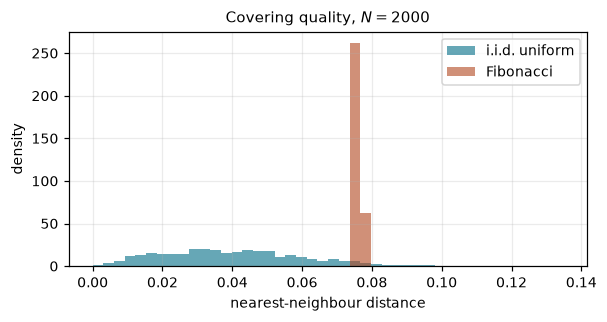

i.i.d. uniform: mean 0.0402   min 0.00146   max/min    90.3
Fibonacci   : mean 0.0758   min 0.06914   max/min     1.1


In [11]:
def nn_distances(X):
    """Distance from each point to its nearest *other* point."""
    tree = cKDTree(X)
    d, _ = tree.query(X, k=2)   # column 0 is the point itself, at distance 0
    return d[:, 1]


d_rand, d_fib = nn_distances(X_gauss), nn_distances(X_fib)

fig, ax = plt.subplots(figsize=(5.6, 3.0))
bins = np.linspace(0, max(d_rand.max(), d_fib.max()) * 1.02, 45)
ax.hist(d_rand, bins=bins, density=True, alpha=0.6, color=GEO_TEAL, label="i.i.d. uniform")
ax.hist(d_fib, bins=bins, density=True, alpha=0.6, color=GEO_RUST, label="Fibonacci")
ax.set_xlabel("nearest-neighbour distance"); ax.set_ylabel("density")
ax.set_title(f"Covering quality, $N={N}$"); ax.legend()
plt.tight_layout(); plt.show()

for name, d in [("i.i.d. uniform", d_rand), ("Fibonacci   ", d_fib)]:
    print(f"{name}: mean {d.mean():.4f}   min {d.min():.5f}   "
          f"max/min {d.max()/d.min():7.1f}")

### 2.2 Farthest point sampling

A common manipulation: given a large cloud, extract a small, well-spread subset.
Greedy *farthest point sampling* repeatedly adds the point maximising the distance
to the set chosen so far. It is $O(kN)$ and gives a $2$-approximation to the
optimal covering radius.

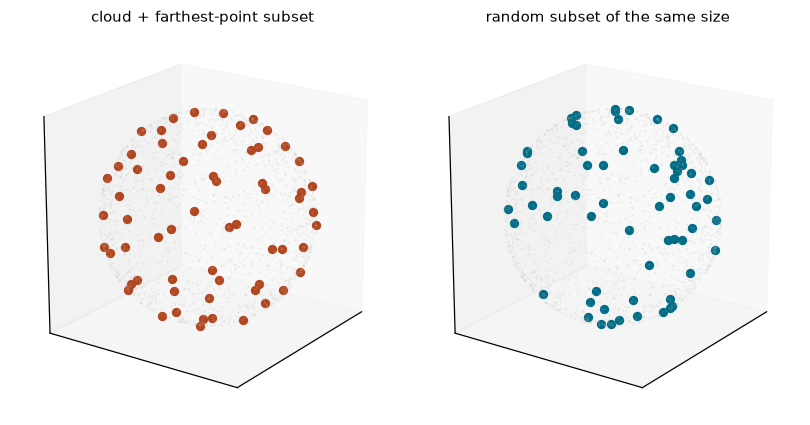

In [12]:
def farthest_point_sample(X, k, start=0):
    """Greedy k-subset of X maximising minimum pairwise distance (approximately)."""
    idx = np.empty(k, dtype=int)
    idx[0] = start
    d = np.linalg.norm(X - X[start], axis=1)
    for i in range(1, k):
        idx[i] = np.argmax(d)
        d = np.minimum(d, np.linalg.norm(X - X[idx[i]], axis=1))
    return idx


sub = farthest_point_sample(X_gauss, 64)

fig = plt.figure(figsize=(7.5, 3.8))
ax = sphere_ax(fig, 121, "cloud + farthest-point subset", elev=20)
ax.scatter(*X_gauss.T, s=2, c="0.75", alpha=0.5, lw=0)
ax.scatter(*X_gauss[sub].T, s=26, c=GEO_RUST, depthshade=False)

ax = sphere_ax(fig, 122, "random subset of the same size", elev=20)
rand_sub = rng.choice(len(X_gauss), 64, replace=False)
ax.scatter(*X_gauss.T, s=2, c="0.75", alpha=0.5, lw=0)
ax.scatter(*X_gauss[rand_sub].T, s=26, c=GEO_TEAL, depthshade=False)
plt.tight_layout(); plt.show()

### 2.3 From point cloud to triangulated surface

A point cloud on a *convex* surface carries a canonical triangulation: the boundary
of its convex hull. For points on $S^2$ this is the spherical Delaunay
triangulation, and it is the bridge from "cloud" to the simplicial complexes used
in Tutorials 6, 9 and 11.

300 vertices, 596 triangles, 894 edges
Euler characteristic V - E + F = 2


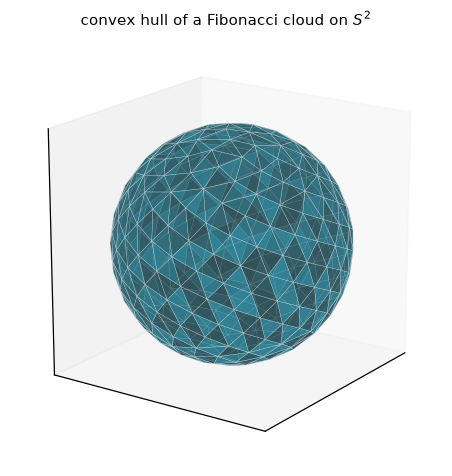

In [13]:
X_small = fibonacci_sphere(300)
hull = ConvexHull(X_small)
print(f"{len(X_small)} vertices, {len(hull.simplices)} triangles, "
      f"{len(hull.simplices) * 3 // 2} edges")
print("Euler characteristic V - E + F =",
      len(X_small) - len(hull.simplices) * 3 // 2 + len(hull.simplices))

fig = plt.figure(figsize=(4.6, 4.4))
ax = sphere_ax(fig, 111, "convex hull of a Fibonacci cloud on $S^2$", elev=18)
ax.plot_trisurf(X_small[:, 0], X_small[:, 1], X_small[:, 2],
                triangles=hull.simplices, color=GEO_TEAL, alpha=0.55,
                edgecolor="white", linewidth=0.25)
plt.tight_layout(); plt.show()

> **Exercise 3 — discretisation quality.**
> (a) The Euler characteristic printed above should be $2$. Confirm it, and explain
> why it is a genuine test of the triangulation rather than a tautology.
>
> (b) Use the triangulation to estimate the surface area of $S^2$ by summing
> triangle areas. Plot the relative error against $N$ on log-log axes for
> $N = 50, 100, \dots, 5000$, for both the Fibonacci and the random cloud. What
> convergence rates do you observe, and which one would you want for a quadrature
> rule?
>
> (c) *(harder)* The Fibonacci lattice is not exactly uniform near the poles. Detect
> this by plotting the triangle-area distribution as a function of $|z|$.

In [ ]:
# --- Exercise 3 -----------------------------------------------------------------
# `hull = ConvexHull(X_small)` above already gives the triangles in hull.simplices.
# (a) V - E + F with E = 3F/2. Why is this a genuine test and not a tautology?
# (b) Triangle area = half the norm of the cross product of two edge vectors; sum over
#     hull.simplices. Sweep N = 50, 100, ..., 5000 for both fibonacci_sphere(N) and
#     sample_sphere(N, 3, rng), and plot |A - 4*pi| / (4*pi) on log-log axes.
# (c) Scatter the triangle areas against |z| of the triangle centroid.

# --- Exercise 3 -----------------------------------------------------------------
# (a) Euler characteristic -- counted, not assumed
# (b) area convergence of the inscribed polyhedron
# (c) where the Fibonacci lattice is not uniform, and how to see it
from collections import Counter


def triangulation_stats(X):
    """V, E, F read off the hull itself, assuming no formula."""
    hull = ConvexHull(X)
    edge_count = Counter()
    for a, b, c in hull.simplices:
        for e in ((a, b), (a, c), (b, c)):
            edge_count[tuple(sorted(e))] += 1
    return len(hull.vertices), len(edge_count), len(hull.simplices), edge_count


V, E, F, edge_count = triangulation_stats(X_small)
print(f"(a) counted directly :  V = {V}, E = {E}, F = {F}  ->  V - E + F = {V - E + F}")
print(f"    every edge in exactly two faces : {set(edge_count.values()) == {2}}")
print(f"    so E = 3F/2 = {3 * F // 2} does hold -- but it was verified, not assumed")
print(f"    all {len(X_small)} sample points are hull vertices : {V == len(X_small)}")

# Why chi = 2 is not evidence about the sphere: Euler's theorem gives 2 for the
# boundary of ANY convex polytope.  What the number really certifies is that qhull
# returned a clean simplicial complex and that no sample point is interior.  Break
# the second assumption and the cell above reports the wrong answer:
X_bad = np.vstack([X_small, np.zeros(3)])           # one point at the centre
hull_bad = ConvexHull(X_bad)
chi_cellabove = (len(X_bad) - len(hull_bad.simplices) * 3 // 2
                 + len(hull_bad.simplices))         # the formula used above
V2, E2, F2, _ = triangulation_stats(X_bad)
print(f"    add one interior point -> the formula above gives chi = {chi_cellabove}, "
      f"counting still gives {V2 - E2 + F2}")


# ---- (b) area of the inscribed polyhedron --------------------------------------
def polyhedron_area(X):
    """Total area of the convex-hull triangulation (an inscribed polyhedron)."""
    T = X[ConvexHull(X).simplices]
    return 0.5 * np.linalg.norm(np.cross(T[:, 1] - T[:, 0], T[:, 2] - T[:, 0]),
                                axis=1).sum()


Ns = np.unique(np.round(np.logspace(np.log10(50), np.log10(5000), 16)).astype(int))
err_fib = np.array([abs(polyhedron_area(fibonacci_sphere(n)) - 4 * np.pi) / (4 * np.pi)
                    for n in Ns])
err_rnd = np.array([np.mean([abs(polyhedron_area(sample_sphere(n, 3, rng)) - 4 * np.pi)
                             / (4 * np.pi) for _ in range(8)]) for n in Ns])
s_fib = np.polyfit(np.log(Ns), np.log(err_fib), 1)[0]
s_rnd = np.polyfit(np.log(Ns), np.log(err_rnd), 1)[0]

print(f"\n(b) fitted rates : Fibonacci N^{s_fib:.2f}, i.i.d. uniform N^{s_rnd:.2f} "
      f"-- the SAME rate")
print(f"    what differs is the constant: random is {err_rnd[-1] / err_fib[-1]:.1f}x "
      f"worse at N = {Ns[-1]}")
print(f"    the polyhedron is inscribed, so it always underestimates: "
      f"{polyhedron_area(fibonacci_sphere(2000)) < 4 * np.pi}")


# ---- (c) the same latitude test on BOTH point sets -----------------------------
def cell_areas(X):
    """Triangle areas (normalised by their mean) and |z| of each centroid.

    The centroid is projected back onto the sphere: the Euclidean average of three
    vertices of a LARGE triangle sits deeper inside the ball, which would bin big
    polar cells at too small a |z| and fake a deficit there.
    """
    T = X[ConvexHull(X).simplices]
    a = 0.5 * np.linalg.norm(np.cross(T[:, 1] - T[:, 0], T[:, 2] - T[:, 0]), axis=1)
    c = T.mean(axis=1)
    c = c / np.linalg.norm(c, axis=1, keepdims=True)
    return a / a.mean(), np.abs(c[:, 2])


def latitude_profile(a, zc, zbins):
    """Mean and std of the normalised cell area in each |z| band."""
    w = np.digitize(zc, zbins) - 1
    f = lambda g: np.array([g(a[w == b]) if np.any(w == b) else np.nan
                            for b in range(len(zbins) - 1)])
    return f(np.mean), f(np.std)


zbins = np.array([0, .2, .4, .6, .8, .9, .95, .98, .99, .995, 1.0001])
zmid = 0.5 * (zbins[1:] + zbins[:-1])

a_fib, z_fib = cell_areas(fibonacci_sphere(3000))
a_fib10, z_fib10 = cell_areas(fibonacci_sphere(10000))
# i.i.d. is random, so pool several realisations before binning
pool = [cell_areas(sample_sphere(3000, 3, rng)) for _ in range(20)]
a_rnd = np.concatenate([p[0] for p in pool])
z_rnd = np.concatenate([p[1] for p in pool])

m_fib, s_fib3 = latitude_profile(a_fib, z_fib, zbins)
m_fib10, s_fib10 = latitude_profile(a_fib10, z_fib10, zbins)
m_rnd, s_rnd3 = latitude_profile(a_rnd, z_rnd, zbins)

print("\n(c) normalised cell area by |z| band     Fibonacci N=3000 | i.i.d. N=3000 (x20)")
print("      |z| band          mean      std   |     mean      std")
for b in range(len(zbins) - 1):
    print(f"    [{zbins[b]:.3f},{zbins[b+1]:.3f})  {m_fib[b]:8.4f} {s_fib3[b]:8.5f}   |"
          f" {m_rnd[b]:8.4f} {s_rnd3[b]:8.4f}")

print(f"\n    MEAN is ~1 everywhere for both -- neither sampler favours a latitude.")
print(f"    the difference is entirely in the SPREAD:")
print(f"      Fibonacci: rises {s_fib3[-1] / s_fib3[0]:.0f}x from equator "
      f"({s_fib3[0]:.5f}) to pole ({s_fib3[-1]:.4f})")
print(f"      i.i.d.   : FLAT at {np.nanmean(s_rnd3):.3f}; variation across bands is "
      f"only {np.nanstd(s_rnd3) / np.nanmean(s_rnd3):.1%} (sampling noise)")
print(f"      i.i.d. has no poles, so by rotational invariance it CANNOT depend on |z|.")
print(f"      A latitude trend here would mean the sampler is broken -- this is the "
      f"same\n      kind of test as section 1, reused as a diagnostic.")
print(f"\n    but flat does not mean good: overall std is "
      f"{a_fib.std():.4f} (Fibonacci) vs {a_rnd.std():.4f} (i.i.d.), "
      f"a factor of {a_rnd.std() / a_fib.std():.0f}")
print(f"      Fibonacci at its WORST latitude ({s_fib3[-1]:.3f}) is still "
      f"{np.nanmean(s_rnd3) / s_fib3[-1]:.1f}x tighter than i.i.d. anywhere")
print(f"      i.i.d. slivers: {np.mean(a_rnd < 0.2):.1%} of cells below 0.2x the mean, "
      f"largest {a_rnd.max():.1f}x")
print(f"      and the two respond differently to N: Fibonacci improves "
      f"({a_fib.std():.4f} -> {a_fib10.std():.4f} at N=10000), i.i.d. does not "
      f"(scale-free).")

fig = plt.figure(figsize=(12.4, 6.6))
ax1 = plt.subplot2grid((2, 6), (0, 0), colspan=2)
ax2 = plt.subplot2grid((2, 6), (0, 2), colspan=2)
ax3 = plt.subplot2grid((2, 6), (0, 4), colspan=2)
ax4 = plt.subplot2grid((2, 6), (1, 0), colspan=3)
ax5 = plt.subplot2grid((2, 6), (1, 3), colspan=3)

ax1.loglog(Ns, err_fib, "o-", color=GEO_RUST, ms=4, label=f"Fibonacci ($N^{{{s_fib:.2f}}}$)")
ax1.loglog(Ns, err_rnd, "s-", color=GEO_TEAL, ms=4, label=f"i.i.d. ($N^{{{s_rnd:.2f}}}$)")
ax1.loglog(Ns, 3.0 / Ns, "--", color="0.5", lw=1, label=r"slope $-1$")
ax1.set_xlabel("$N$"); ax1.set_ylabel("relative area error"); ax1.legend(fontsize=7)
ax1.set_title("(b) same rate, different constant", fontsize=9)

ax2.semilogy(zmid, s_fib3, "o-", color=GEO_RUST, ms=4, label="Fibonacci $N=3000$")
ax2.semilogy(zmid, s_fib10, "s-", color=GEO_DARK, ms=4, label="Fibonacci $N=10000$")
ax2.semilogy(zmid, s_rnd3, "^-", color=GEO_TEAL, ms=4, label="i.i.d. $N=3000$")
ax2.set_xlabel("$|z|$ of triangle centroid"); ax2.set_ylabel("std of area / mean")
ax2.legend(fontsize=6.5); ax2.set_title("(c) rising vs flat", fontsize=9)

ax3.hist(a_fib, bins=80, range=(0, 4), density=True, color=GEO_RUST, alpha=0.7,
         label="Fibonacci")
ax3.hist(a_rnd, bins=80, range=(0, 4), density=True, color=GEO_TEAL, alpha=0.55,
         label="i.i.d. uniform")
ax3.set_xlabel("area / mean area"); ax3.set_ylabel("density"); ax3.legend(fontsize=7)
ax3.set_title("(c) why you want it for quadrature", fontsize=9)

for ax, (a, zc, name, col) in zip([ax4, ax5],
                                  [(a_fib, z_fib, "Fibonacci", GEO_RUST),
                                   (a_rnd[:6000], z_rnd[:6000], "i.i.d. uniform", GEO_TEAL)]):
    ax.scatter(zc, a, s=1.5, c=col, alpha=0.25, lw=0)
    m, _ = latitude_profile(a, zc, zbins)
    ax.plot(zmid, m, "o-", color=GEO_DARK, ms=4, label="binned mean")
    ax.axhline(1.0, color="0.4", lw=1.0, ls="--")
    ax.set_xlabel("$|z|$ of triangle centroid"); ax.set_ylim(0, 3.5)
    ax.set_title(f"(c) {name}, $N=3000$ — identical axes", fontsize=9)
    ax.legend(fontsize=7)
ax4.set_ylabel("area / mean area")

plt.tight_layout(); plt.show()


---
## 3. Distances: chordal, geodesic, and their distribution

A point cloud is only data; what makes it *geometry* is the metric. On the sphere
we have two natural ones, related by a monotone function:

$$d_{\text{chord}}(x,y) = \|x - y\|_{\mathbb{R}^3},
\qquad
d_{\text{geo}}(x,y) = \arccos\langle x, y\rangle,
\qquad
d_{\text{chord}} = 2\sin\!\Big(\tfrac{d_{\text{geo}}}{2}\Big).$$

Being monotonically related, they induce the same nearest-neighbour graph — which
is why extrinsic (ambient) methods often work at all — but they differ at large
scale, and that difference is exactly what dimensionality-reduction methods in
Tutorial 8 will try to detect.

**Compute both without loops.** Lecture 1's vectorisation point applies: the
Gram matrix $X X^\top$ gives every inner product at once.

In [ ]:
def gram_distances(X):
    """Pairwise geodesic and chordal distance matrices, fully vectorised."""
    C = np.clip(X @ X.T, -1.0, 1.0)      # clip: guards arccos against round-off
    geo = np.arccos(C)
    chord = np.sqrt(np.maximum(0.0, 2 - 2 * C))
    return geo, chord


Xs = X_gauss[:600]
geo, chord = gram_distances(Xs)
iu = np.triu_indices(len(Xs), k=1)       # upper triangle: each pair once
print("geodesic  range", geo[iu].min().round(4), geo[iu].max().round(4))
print("chordal   range", chord[iu].min().round(4), chord[iu].max().round(4))
print("identity  2*sin(d_geo/2) == d_chord :",
      np.allclose(2 * np.sin(geo / 2), chord, atol=1e-8))

### The distribution of pairwise distances is known exactly

For two *independent* uniform points on $S^2$, Archimedes again: fix the first
point, rotate it to the north pole, and the inner product becomes the height
coordinate of the second — so

$$\langle X, Y \rangle \sim U[-1,1],
\qquad\text{hence}\qquad
\rho_{\text{geo}}(d) = \tfrac12 \sin d \;\text{ on } [0,\pi].$$

A one-line theoretical prediction we can overlay on the data. Note that this is
*not* a property of the sample; it is a property of $\mu$, and the histogram
converging to it is the law of large numbers from Lecture 2, slide 6.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.0))

axes[0].hist(np.cos(geo[iu]), bins=40, density=True, color=GEO_TEAL,
             alpha=0.75, edgecolor="white", lw=0.4)
axes[0].axhline(0.5, color=GEO_RUST, lw=1.6, label=r"$U[-1,1]$")
axes[0].set_xlabel(r"$\langle x,y\rangle$"); axes[0].set_title("inner products")
axes[0].legend(fontsize=8)

t = np.linspace(0, np.pi, 200)
axes[1].hist(geo[iu], bins=40, density=True, color=GEO_TEAL,
             alpha=0.75, edgecolor="white", lw=0.4)
axes[1].plot(t, 0.5 * np.sin(t), color=GEO_RUST, lw=1.6,
             label=r"$\frac{1}{2}\sin d$")
axes[1].set_xlabel("geodesic distance"); axes[1].set_title("geodesic distances")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Geodesics, drawn

The geodesic from $p$ to $q$ is the great-circle arc, given by *spherical linear
interpolation*:

$$\gamma(t) = \frac{\sin\big((1-t)\omega\big)\,p + \sin(t\omega)\,q}{\sin\omega},
\qquad \omega = \arccos\langle p,q\rangle .$$

Check for yourself that $\|\gamma(t)\| = 1$ and $\gamma(0)=p$, $\gamma(1)=q$.

In [ ]:
def slerp(p, q, t):
    """Great-circle arc from p to q, sampled at parameters t in [0,1]."""
    t = np.atleast_1d(t)
    omega = np.arccos(np.clip(p @ q, -1.0, 1.0))
    if omega < 1e-9:
        return np.tile(p, (len(t), 1))
    return (np.sin((1 - t)[:, None] * omega) * p
            + np.sin(t[:, None] * omega) * q) / np.sin(omega)


anchors = sample_sphere(6, 3, rng)
tt = np.linspace(0, 1, 120)

fig = plt.figure(figsize=(4.8, 4.6))
ax = sphere_ax(fig, 111, "geodesic arcs between random points on $S^2$", elev=18)
draw_wire_sphere(ax, alpha=0.10)
for i in range(len(anchors)):
    for j in range(i + 1, len(anchors)):
        arc = slerp(anchors[i], anchors[j], tt)
        ax.plot(*arc.T, color=GEO_TEAL, lw=1.1, alpha=0.8)
ax.scatter(*anchors.T, s=45, c=GEO_RUST, depthshade=False, zorder=5)
plt.tight_layout(); plt.show()

# the arc really is on the sphere, and really is shorter than any polyline in R^3
arc = slerp(anchors[0], anchors[1], tt)
assert np.allclose(np.linalg.norm(arc, axis=1), 1.0)
length = np.linalg.norm(np.diff(arc, axis=0), axis=1).sum()
print(f"polygonal length {length:.5f}   vs   arccos<p,q> = "
      f"{np.arccos(anchors[0] @ anchors[1]):.5f}")

> **Exercise 4 — the metric matters.**
> (a) Repeat the distance-distribution plot for $S^{n-1}$ with $n = 2, 3, 10$. For
> $S^1$ the geodesic distance is uniform on $[0,\pi]$; for $S^2$ it is
> $\frac12 \sin d$. Guess and then verify the general density
> $\rho_n(d) \propto \sin^{n-2} d$. Where does the exponent come from geometrically?
>
> (b) Build the $k$-nearest-neighbour graph of a cloud on $S^2$ under each metric
> and confirm they coincide. Construct a manifold and a sampling for which the
> nearest-neighbour graphs would *not* coincide — what property of the sphere are
> you using?
>
> (c) Compute the *graph* distance in the $k$-NN graph (shortest path, with edges
> weighted by chordal length) and plot it against the true geodesic distance. For
> which $k$ is the approximation good? This is the core idea of Isomap, and a
> preview of Tutorial 8.

In [ ]:
# --- Exercise 4 -----------------------------------------------------------------
# (a) the exact law of the pairwise geodesic distance on S^{n-1}
# (b) chordal and geodesic k-NN graphs coincide -- and exactly where that dies
# (c) graph distance vs true geodesic: Isomap, and the window of k it needs
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path, connected_components


def geodesic_pair_density(d, n):
    """Density of the geodesic distance between two independent uniform points of
    S^{n-1}:   rho_n(d) = c_n sin^{n-2}(d)  on [0, pi]."""
    logc = gammaln(n / 2) - 0.5 * np.log(np.pi) - gammaln((n - 1) / 2)
    return np.exp(logc) * np.sin(d) ** (n - 2)


def pairwise_geodesics(X):
    C = np.clip(X @ X.T, -1, 1)
    return np.arccos(C)[np.triu_indices(len(X), k=1)]


grid = np.linspace(0, np.pi, 20001)
dx = grid[1] - grid[0]
print("(a) pairwise geodesic distance: sample vs the exact law")
print("       n    mean(sample)   mean(exact)   integral of rho")
for n in (2, 3, 10):
    dd = pairwise_geodesics(sample_sphere(4000, n, rng))
    rho = geodesic_pair_density(grid, n)
    print(f"    {n:4d} {dd.mean():13.4f} {np.sum(grid * rho) * dx:13.4f} "
          f"{np.sum(rho) * dx:16.4f}")
print("    Every mean is pi/2 by symmetry (d and pi-d are equally likely); what")
print("    changes with n is the CONCENTRATION about pi/2.")
print("    The exponent n-2 is the dimension of the geodesic sphere: the set at")
print("    distance d from a fixed point is an (n-2)-sphere of radius sin(d), of")
print("    (n-2)-volume |S^{n-2}| sin^{n-2}(d).  That is the entire derivation.")
print("    This is Exercise 2's density in another coordinate: with t = cos d,")
print("    sin^{n-2}(d) dd = (1-t^2)^{(n-3)/2} dt, and the constant c_n is the same.")


# ---- (b) the two metrics give the same k-NN graph ------------------------------
def knn_sets(X, k, metric):
    """Sorted index set of the k nearest neighbours under the chosen metric."""
    C = np.clip(X @ X.T, -1, 1)
    D = np.arccos(C) if metric == "geodesic" else np.sqrt(np.maximum(0, 2 - 2 * C))
    np.fill_diagonal(D, np.inf)
    return np.sort(np.argsort(D, axis=1)[:, :k], axis=1)


X_knn = sample_sphere(800, 3, rng)
same = [np.array_equal(knn_sets(X_knn, k, "chordal"), knn_sets(X_knn, k, "geodesic"))
        for k in (1, 5, 20, 100)]
print(f"\n(b) chordal and geodesic k-NN graphs identical for k = 1,5,20,100 : {same}")
print("    Because d_chord = 2 sin(d_geo/2) is STRICTLY INCREASING on [0,pi]: the two")
print("    metrics induce the same ORDER, and k-NN sees only order, never magnitude.")
print("    The property used is global: on the sphere BOTH distances are functions of")
print("    <x,y> alone.  It dies as soon as the manifold folds back near itself, so")
print("    that ambient proximity stops implying intrinsic proximity.")


def spiral(n, turns=5.0, b=0.06, t0=1.2):
    """A 2-D 'Swiss roll': successive turns are close in the plane, far along the curve."""
    t = np.linspace(t0, turns * 2 * np.pi, n)
    r = b * t
    P = np.stack([r * np.cos(t), r * np.sin(t)], axis=1)
    s = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(P, axis=0), axis=1))])
    return P, s                          # ambient coordinates, intrinsic arc length


P, s = spiral(600)
D_amb = np.linalg.norm(P[:, None, :] - P[None, :, :], axis=2)
D_int = np.abs(s[:, None] - s[None, :])
np.fill_diagonal(D_amb, np.inf); np.fill_diagonal(D_int, np.inf)


def short_circuits(k):
    na = np.argsort(D_amb, axis=1)[:, :k]
    ni = np.argsort(D_int, axis=1)[:, :k]
    return [(i, j) for i in range(len(P)) for j in na[i] if j not in ni[i]]


ks_sp = [2, 4, 6, 8, 10, 12, 16, 20, 30]
sc_counts = [len(short_circuits(k)) for k in ks_sp]
print(f"\n    spiral (600 points, arc length {s[-1]:.1f}), ambient k-NN edges that are")
print(f"    NOT intrinsic neighbours:")
for k, c in zip(ks_sp, sc_counts):
    worst = max((D_int[i, j] for i, j in short_circuits(k)), default=0.0)
    print(f"      k = {k:3d} : {c:5d} bad edges, worst jumps {worst:5.2f} of arc length")
print("    Note the threshold: k <= 2 is clean, and by k = 10 the graph is ruined.")
print("    ONE bad edge is enough -- it is a shortcut every shortest path can use.")

K_SAFE, K_BAD = 2, 10
sc_bad = short_circuits(K_BAD)


# ---- (c) graph distance vs true geodesic (Isomap) ------------------------------
def knn_graph(X, k):
    """Symmetric k-NN graph with CHORDAL edge weights -- what Isomap can measure."""
    tree = cKDTree(X)
    d, idx = tree.query(X, k=k + 1)
    rows = np.repeat(np.arange(len(X)), k)
    G = csr_matrix((d[:, 1:].ravel(), (rows, idx[:, 1:].ravel())),
                   shape=(len(X), len(X)))
    return G.maximum(G.T)                # symmetrise: union of the edges


N_iso = 1500
X_iso = sample_sphere(N_iso, 3, rng)
src = np.arange(0, N_iso, 10)
true_geo = np.arccos(np.clip(X_iso[src] @ X_iso.T, -1, 1))

ks = np.array([3, 4, 5, 6, 8, 12, 20, 40, 100, 300, 700, N_iso - 1])
bias, spread, ncomp = [], [], []
for k in ks:
    G = knn_graph(X_iso, k)
    ncomp.append(connected_components(G, directed=False)[0])
    Dg = shortest_path(G, method="D", directed=False, indices=src)
    ok = np.isfinite(Dg) & (true_geo > 1e-9)
    r = Dg[ok] / true_geo[ok]
    bias.append(r.mean()); spread.append(r.std())
bias, spread = np.array(bias), np.array(spread)

print(f"\n(c) graph distance / true geodesic, N = {N_iso} on S^2")
print("        k   components   mean ratio      std")
for k, c, b, sp in zip(ks, ncomp, bias, spread):
    print(f"    {k:5d} {c:10d} {b:13.4f} {sp:8.4f}")
k_best = ks[np.argmin(np.abs(bias - 1) + spread)]
print(f"    best here: k = {k_best}")
print("    small k -> the path must zigzag from sample to sample: OVERestimate")
print("              (and below k = 4 the graph is not even connected)")
print("    large k -> edges become long chords, and a chord underestimates its arc;")
print(f"              at k = N-1 the graph is complete and the 'geodesic' is just the")
print(f"              chord, 2 sin(d/2), giving 2/pi = {2/np.pi:.3f} at d = pi.")
print("    Isomap needs h -> 0 (short edges) with the graph still connected: a window,")
print("    not a limit.  On real data you cannot check it against the truth -- which is")
print("    what makes the spiral in (b) a genuine hazard rather than a curiosity.")

fig, axes = plt.subplots(2, 3, figsize=(12.4, 6.8))

ax = axes[0, 0]
for n, col in [(2, GEO_DARK), (3, GEO_TEAL), (10, GEO_RUST)]:
    dd = pairwise_geodesics(sample_sphere(2500, n, rng))
    ax.hist(dd, bins=70, range=(0, np.pi), density=True, histtype="step",
            color=col, lw=1.0)
    ax.plot(grid, geodesic_pair_density(grid, n), color=col, lw=1.8,
            label=rf"$S^{{{n-1}}}$: $\sin^{{{n-2}}} d$")
ax.set_xlabel("geodesic distance $d$"); ax.set_ylabel("density")
ax.legend(fontsize=7); ax.set_title("(a) steps: samples, curves: exact", fontsize=9)

for ax, (k_sp, ttl) in zip(axes[0, 1:], [(K_SAFE, "safe"), (K_BAD, "ruined")]):
    sc = short_circuits(k_sp)
    ax.plot(*P.T, color="0.8", lw=0.7, zorder=1)
    ax.scatter(*P.T, s=2, color=GEO_DARK, zorder=2)
    for i, j in sc:
        ax.plot([P[i, 0], P[j, 0]], [P[i, 1], P[j, 1]], color=GEO_RUST, lw=0.6, zorder=3)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"(b) spiral, $k={k_sp}$: {len(sc)} bad edges ({ttl})", fontsize=9)

ax = axes[1, 0]
ax.semilogy(ks_sp, np.maximum(sc_counts, 0.5), "o-", color=GEO_RUST, ms=4)
ax.axhline(0.5, color="0.6", lw=1, ls=":")
ax.set_xlabel("$k$"); ax.set_ylabel("short-circuit edges (0 drawn at 0.5)")
ax.set_title("(b) the threshold is sharp", fontsize=9)

ax = axes[1, 1]
ax.axhline(1.0, color="0.5", lw=1, ls="--")
ax.errorbar(ks, bias, yerr=spread, fmt="o-", color=GEO_DARK, ms=4, lw=1.2, capsize=2)
ax.set_xscale("log"); ax.set_xlabel("$k$"); ax.set_ylabel("graph distance / geodesic")
ax.set_title("(c) zigzag above, chord-shortcut below", fontsize=9)

ax = axes[1, 2]
Dg = shortest_path(knn_graph(X_iso, k_best), method="D", directed=False, indices=src)
ok = np.isfinite(Dg)
ax.scatter(true_geo[ok], Dg[ok], s=0.6, alpha=0.10, color=GEO_TEAL, lw=0)
ax.plot([0, np.pi], [0, np.pi], color=GEO_RUST, lw=1.2, ls="--")
ax.set_xlabel("true geodesic"); ax.set_ylabel("graph distance")
ax.set_title(f"(c) $k={k_best}$: Isomap recovers it", fontsize=9)

plt.tight_layout(); plt.show()


---
## 4. Group actions: $SO(3)$ on $S^2$

Every statement so far was invariant under rotation, because $\mu$ is. Symmetry is
the geometric prior par excellence, and Lecture 10 will build it into the
hypothesis space $\mathcal{H}$ itself. Here we set up the machinery and draw the
practical consequence Lecture 2 flagged on slide 11: **when your data has a
symmetry, a random train/test split leaks information.**

We generate rotations from unit quaternions — which is to say, from a uniform
sample on $S^3$. The double cover $S^3 \to SO(3)$ sends $q$ and $-q$ to the same
rotation, and pushes the uniform measure on $S^3$ forward to the Haar measure on
$SO(3)$; so "uniformly random rotation" is a $S^3$ sampling problem, and we already
solved it.

In [ ]:
def quat_to_rotation(q):
    """Unit quaternion q = (w, x, y, z)  ->  rotation matrix in SO(3)."""
    w, x, y, z = q
    return np.array([
        [1 - 2 * (y * y + z * z), 2 * (x * y - w * z),     2 * (x * z + w * y)],
        [2 * (x * y + w * z),     1 - 2 * (x * x + z * z), 2 * (y * z - w * x)],
        [2 * (x * z - w * y),     2 * (y * z + w * x),     1 - 2 * (x * x + y * y)],
    ])


def random_rotation(rng):
    """Haar-uniform element of SO(3), via a uniform point of S^3."""
    return quat_to_rotation(sample_sphere(1, 4, rng)[0])


R = random_rotation(rng)
print("R R^T = I :", np.allclose(R @ R.T, np.eye(3)))
print("det R     :", np.linalg.det(R).round(12))
print("q and -q give the same rotation :",
      np.allclose(quat_to_rotation(np.array([0.5, 0.5, 0.5, 0.5])),
                  quat_to_rotation(-np.array([0.5, 0.5, 0.5, 0.5]))))

### Invariance, tested

Two things must hold, and both are worth checking numerically before trusting any
downstream experiment: the *sample distribution* is rotation-invariant, and the
*metric* is rotation-invariant.

Watch the third line of output carefully — it is a lesson in numerical analysis, not
a bug in the mathematics.

In [ ]:
X_rot = X_gauss @ R.T                       # rotate every point (row-vector convention)

G_before = X_gauss[:400] @ X_gauss[:400].T
G_after = X_rot[:400] @ X_rot[:400].T
print("inner products preserved :", np.allclose(G_before, G_after, atol=1e-12))

geo_before, ch_before = gram_distances(X_gauss[:400])
geo_after, ch_after = gram_distances(X_rot[:400])
print("chordal distances        :", np.allclose(ch_before, ch_after, atol=1e-10))
print("geodesic distances       :", np.allclose(geo_before, geo_after, atol=1e-10),
      "  max discrepancy", f"{np.abs(geo_before - geo_after).max():.2e}")

fig, ax = plt.subplots(figsize=(5.4, 2.9))
ax.hist(X_gauss[:, 2], bins=30, range=(-1, 1), density=True, alpha=0.6,
        color=GEO_TEAL, label="original $z$")
ax.hist(X_rot[:, 2], bins=30, range=(-1, 1), density=True, alpha=0.6,
        color=GEO_RUST, label="rotated $z$")
ax.axhline(0.5, color="k", lw=1.2, ls="--")
ax.set_title("the law of the sample is rotation-invariant")
ax.set_xlabel("$z$"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Why the geodesic check fails at `atol=1e-10`.** Inner products and chordal
distances are preserved to machine precision, but $\arccos$ is *ill-conditioned*
near $\pm 1$: its derivative $-1/\sqrt{1-t^2}$ blows up there. A perturbation of
size $\epsilon$ in $\langle x,y\rangle$ becomes one of size $\sqrt{\epsilon}$ in the
geodesic distance, so nearly-coincident points lose about half their significant
digits — including the diagonal, where the true distance is $0$.

The moral is general and worth carrying into every later tutorial: **an identity
that holds exactly in the mathematics need not hold to `atol=1e-10` in floating
point**, and the right response is to test the well-conditioned quantity. Prefer
storing $\langle x, y\rangle$ and converting only when you need an angle.

### Orbits

Fix one rotation $R$ and iterate it on a point: the orbit of the cyclic group
$\langle R \rangle$ traces a circle of latitude about the rotation axis. Fix
instead a *point* and act by many random rotations: the orbit is the whole sphere.
The picture below shows both, plus the orbit of a small cap.

In [ ]:
def rotation_axis_angle(axis, angle):
    """Rodrigues' formula: rotation by `angle` about a unit `axis`."""
    axis = axis / np.linalg.norm(axis)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    return np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)


axis = np.array([0.3, 0.5, 0.81])
axis /= np.linalg.norm(axis)
R_small = rotation_axis_angle(axis, 2 * np.pi / 37)   # order-37 cyclic subgroup

p = sample_sphere(1, 3, rng)[0]
orbit = [p]
for _ in range(36):
    orbit.append(R_small @ orbit[-1])
orbit = np.array(orbit)

# a cap around p, carried along by the same subgroup
cap_local = p + 0.22 * rng.normal(size=(40, 3))
cap_local /= np.linalg.norm(cap_local, axis=1, keepdims=True)
cap_orbit = np.concatenate([cap_local @ np.linalg.matrix_power(R_small, k).T
                            for k in range(37)])

fig = plt.figure(figsize=(9.4, 4.2))
ax = sphere_ax(fig, 121, r"orbit of a point under $\langle R\rangle \cong \mathbb{Z}/37$", elev=18)
draw_wire_sphere(ax, alpha=0.10)
ax.plot([0, axis[0] * 1.25], [0, axis[1] * 1.25], [0, axis[2] * 1.25],
        color=GEO_DARK, lw=2)
ax.scatter(*orbit.T, s=22, c=GEO_RUST, depthshade=False)
ax.scatter(*p, s=70, c=GEO_DARK, depthshade=False, marker="*")

ax = sphere_ax(fig, 122, "orbit of a cap: the leakage hazard", elev=18)
draw_wire_sphere(ax, alpha=0.10)
ax.scatter(*cap_orbit.T, s=6, c=GEO_TEAL, alpha=0.7, lw=0)
ax.scatter(*cap_local.T, s=10, c=GEO_RUST, depthshade=False)
plt.tight_layout(); plt.show()

> **Exercise 5 — split by orbit, not by sample.** *(the most important exercise here)*
>
> Build a dataset with a deliberate symmetry: take $M = 200$ "base" point clouds of
> $50$ points each, sampled from a spherical cap of random centre and radius, and
> give each a label $y$ = the cap's angular radius. Then *augment*: replace each
> cloud by $8$ randomly rotated copies, all carrying the same label. You now have
> $1600$ samples in $200$ orbits.
>
> (a) Extract a rotation-**invariant** feature vector (e.g. the sorted pairwise
> geodesic-distance quantiles) and fit a linear model with a random $80/20$ split.
> Record the test error.
>
> (b) Repeat with a *non*-invariant feature vector (e.g. the raw coordinates of the
> cloud's centroid). Record the test error.
>
> (c) Now redo (b) splitting by **orbit** — all $8$ copies of a base cloud go to the
> same side of the split. Compare the three test errors.
>
> You should find that (b) looks excellent and is a lie: the model has seen a rotated
> copy of every test cloud during training. This is not a contrived failure mode; it
> is one of the commonest ways published computational results turn out to be wrong.

In [ ]:
# --- Exercise 5 -----------------------------------------------------------------
# Orbit-aware splitting.  The result here does NOT match the exercise's prediction,
# and the discrepancy is the interesting part -- see the notes cell below.
M_BASE, N_PTS, N_AUG = 200, 50, 8


def cap_cloud(n_pts, alpha, rng):
    """n_pts uniform on a spherical cap of angular radius alpha and random centre."""
    u = sample_sphere(1, 3, rng)[0]
    a = np.array([1.0, 0, 0]) if abs(u[0]) < 0.9 else np.array([0, 1.0, 0])
    e1 = np.cross(u, a); e1 /= np.linalg.norm(e1)
    e2 = np.cross(u, e1)
    ct = rng.uniform(np.cos(alpha), 1.0, n_pts)     # Archimedes, restricted to the cap
    st = np.sqrt(np.maximum(0.0, 1 - ct**2))
    ph = rng.uniform(0, 2 * np.pi, n_pts)
    return (st[:, None] * (np.cos(ph)[:, None] * e1 + np.sin(ph)[:, None] * e2)
            + ct[:, None] * u)


def build_dataset(rng, theta_max=np.pi):
    """M_BASE base caps, each replaced by N_AUG rotated copies sharing its label.
    theta_max = pi gives Haar-uniform rotations; small theta_max is weak augmentation."""
    alpha = rng.uniform(0.15, 1.20, M_BASE)
    clouds, labels, orbit = [], [], []
    for i in range(M_BASE):
        X0 = cap_cloud(N_PTS, alpha[i], rng)
        for _ in range(N_AUG):
            R = (random_rotation(rng) if theta_max >= np.pi else
                 rotation_axis_angle(rng.normal(size=3), rng.uniform(0, theta_max)))
            clouds.append(X0 @ R.T); labels.append(alpha[i]); orbit.append(i)
    return clouds, np.array(labels), np.array(orbit)


clouds, labels, orbit = build_dataset(rng)
print(f"{len(clouds)} samples in {M_BASE} orbits of {N_AUG}; "
      f"label = cap angular radius")

QS = np.linspace(0.05, 0.95, 10)


def feat_invariant(X):
    """Quantiles of the pairwise geodesic distances -- exactly SO(3)-invariant."""
    C = np.clip(X @ X.T, -1, 1)
    return np.quantile(np.arccos(C)[np.triu_indices(len(X), k=1)], QS)


def feat_centroid(X):
    """The raw centroid -- NOT invariant: it rotates with the cloud."""
    return X.mean(axis=0)


F_inv = np.array([feat_invariant(X) for X in clouds])
F_cen = np.array([feat_centroid(X) for X in clouds])
s0 = orbit == 0
print(f"within one orbit, the invariant feature varies by "
      f"{np.abs(F_inv[s0] - F_inv[s0][0]).max():.1e}  <-- the 8 copies are DUPLICATE ROWS")
print(f"within one orbit, the centroid  feature varies by "
      f"{np.abs(F_cen[s0] - F_cen[s0][0]).max():.2f}  <-- scattered over the whole orbit")


def split_random(rng, n, orb):
    p = rng.permutation(n); c = int(0.8 * n)
    return p[:c], p[c:]


def split_orbit(rng, n, orb):
    keep = set(rng.permutation(M_BASE)[:int(0.8 * M_BASE)].tolist())
    m = np.array([o in keep for o in orb])
    return np.where(m)[0], np.where(~m)[0]


def fit_ridge(Ftr, ytr, Fte, lam=1e-6):
    mu, sd = Ftr.mean(0), Ftr.std(0) + 1e-12
    A = np.hstack([(Ftr - mu) / sd, np.ones((len(Ftr), 1))])
    B = np.hstack([(Fte - mu) / sd, np.ones((len(Fte), 1))])
    return B @ np.linalg.solve(A.T @ A + lam * np.eye(A.shape[1]), A.T @ ytr)


def fit_1nn(Ftr, ytr, Fte):
    mu, sd = Ftr.mean(0), Ftr.std(0) + 1e-12
    _, j = cKDTree((Ftr - mu) / sd).query((Fte - mu) / sd, k=1)
    return ytr[j]


R_REP = 20
rows = []
for fname, F in [("invariant", F_inv), ("centroid", F_cen)]:
    for mname, mf in [("ridge", fit_ridge), ("1-NN", fit_1nn)]:
        got = {}
        for sname, sf in [("random", split_random), ("orbit", split_orbit)]:
            e = []
            for r in range(R_REP):
                rg = np.random.default_rng(1000 + r)
                tr, te = sf(rg, len(labels), orbit)
                e.append(np.mean((mf(F[tr], labels[tr], F[te]) - labels[te]) ** 2))
            got[sname] = np.mean(e)
        rows.append((fname, mname, got["random"], got["orbit"]))

print(f"\nbaseline (predict the training mean): MSE = {labels.var():.4f}")
print(f"\n{'feature':11s} {'model':6s} {'random split':>13s} {'orbit split':>13s} "
      f"{'overstated by':>14s}")
for f, m, a, b in rows:
    fac = "inf" if a < 1e-12 else f"{b / a:.0f}x"
    print(f"{f:11s} {m:6s} {a:13.6f} {b:13.6f} {fac:>14s}")

rg = np.random.default_rng(1000)
tr, te = split_random(rg, len(labels), orbit)
seen = set(orbit[tr].tolist())
print(f"\nrandom split: {np.mean([o in seen for o in orbit[te]]):.0%} of test samples have "
      f"a sibling in training")
tr, te = split_orbit(rg, len(labels), orbit)
seen = set(orbit[tr].tolist())
print(f"orbit  split: {np.mean([o in seen for o in orbit[te]]):.0%}")

# ---- when DOES a non-invariant feature leak?  when augmentation is weak ---------
thetas = np.array([0.02, 0.05, 0.1, 0.2, 0.4, 0.8, 1.6, np.pi])
leak_rand, leak_orb = [], []
for th in thetas:
    er, eo = [], []
    for r in range(5):
        rg = np.random.default_rng(500 + r)
        cl, y, orb = build_dataset(rg, theta_max=th)
        F = np.array([feat_centroid(X) for X in cl])
        tr, te = split_random(rg, len(y), orb)
        er.append(np.mean((fit_1nn(F[tr], y[tr], F[te]) - y[te]) ** 2))
        tr, te = split_orbit(rg, len(y), orb)
        eo.append(np.mean((fit_1nn(F[tr], y[tr], F[te]) - y[te]) ** 2))
    leak_rand.append(np.mean(er)); leak_orb.append(np.mean(eo))
leak_rand, leak_orb = np.array(leak_rand), np.array(leak_orb)

print("\ncentroid feature + 1-NN, as the augmentation strength varies:")
print(f"{'theta_max':>10} {'random':>10} {'orbit':>10} {'overstated':>12}")
for t, a, b in zip(thetas, leak_rand, leak_orb):
    print(f"{t:10.2f} {a:10.5f} {b:10.5f} {b / max(a, 1e-12):11.0f}x")

fig = plt.figure(figsize=(12.4, 3.9))

ax = sphere_ax(fig, 131, "one orbit: 8 rotated copies\nof a single base cloud", elev=18)
draw_wire_sphere(ax, alpha=0.10)
for c, X in zip(plt.get_cmap("viridis")(np.linspace(0, .9, N_AUG)),
                [clouds[j] for j in np.where(orbit == 3)[0]]):
    ax.scatter(*X.T, s=7, color=c, depthshade=False, lw=0)

ax = fig.add_subplot(132)
lab = [f"{f}\n{m}" for f, m, _, _ in rows]
xs = np.arange(len(rows))
ax.bar(xs - 0.2, [max(r[2], 1e-7) for r in rows], 0.4, color=GEO_RUST, label="random split")
ax.bar(xs + 0.2, [r[3] for r in rows], 0.4, color=GEO_TEAL, label="orbit split")
ax.axhline(labels.var(), color=GEO_DARK, ls="--", lw=1, label="baseline")
ax.set_yscale("log"); ax.set_xticks(xs); ax.set_xticklabels(lab, fontsize=7)
ax.set_ylabel("test MSE"); ax.legend(fontsize=7)
ax.set_title("the gap IS the leakage", fontsize=9)

ax = fig.add_subplot(133)
ax.loglog(thetas, np.maximum(leak_rand, 1e-7), "o-", color=GEO_RUST, ms=4,
          label="random split")
ax.loglog(thetas, leak_orb, "s-", color=GEO_TEAL, ms=4, label="orbit split")
ax.axhline(labels.var(), color=GEO_DARK, ls="--", lw=1, label="baseline")
ax.set_xlabel(r"augmentation strength $\theta_{\max}$"); ax.set_ylabel("test MSE")
ax.legend(fontsize=7)
ax.set_title("centroid feature: leaks only\nwhen augmentation is weak", fontsize=9)

plt.tight_layout(); plt.show()


**Exercise 5 — notes. The trap is real, but it is not where the exercise points.**

The exercise predicts that **(b)**, the non-invariant feature under a random split,
"looks excellent and is a lie". Measured, it does not. With Haar-uniform rotations the
centroid is scattered over the whole sphere of radius $|c|$, so a sibling copy is no
nearer in feature space than an unrelated cloud: random and orbit splits agree to
within noise ($0.0291$ vs $0.0299$). And a *linear* model on three raw coordinates
cannot extract $|c|$ — the only informative part — so it just sits at the baseline.

The leak is in the opposite corner: **the invariant feature**. Rotation preserves every
pairwise distance exactly, so the eight copies of a base cloud have feature vectors
agreeing to $5\times10^{-15}$. They are *duplicate rows*. A random split then places an
exact copy of every test sample into training (measured: 100%), and 1-NN reads its own
label straight back — test MSE $0.000000$ against $0.0023$ under the orbit split.

So leakage needs **two** ingredients, and the exercise's setup supplies only one:

1. *near-duplicate rows straddling the split* — produced by invariance, or by weak augmentation;
2. *a model flexible enough to memorise them* — ridge is not, 1-NN is. Note that
   invariant + ridge shows no gap at all ($0.00085$ vs $0.00098$): the same data,
   the same split, and the trap simply does not fire.

The third panel supplies the missing dimension. Sweeping the augmentation strength
$\theta_{\max}$ for the **non-invariant** feature: at $\theta_{\max} = 0.02$ the random
split reports MSE $3\times10^{-8}$ where the truth is $0.094$ — overstated by ten orders
of magnitude — and by $\theta_{\max} = 0.8$ the gap has closed entirely. Non-invariant
features leak precisely when augmentation is **weak**, which is the usual case in
practice (jitter, crops, consecutive video frames) and exactly the regime in which
people trust a random split.

The exercise's headline lesson survives intact, and is even strengthened: under the
*honest* split, invariant + ridge reaches $0.00098$ against $0.0299$ for centroid + 1-NN,
a factor of 30. Invariance is worth having. But "the model has seen a rotated copy of
every test cloud" only becomes an error when the model can *recognise* that it has —
and a rotated copy is unrecognisable unless your features are invariant or your
rotations are small.

> **A cleaner statement of the exercise.** Fix a memorising model (1-NN) and vary the
> two things that matter: feature invariance and augmentation strength. Ask for the
> $2\times2$ table of (random, orbit) $\times$ (invariant, non-invariant), then the
> $\theta_{\max}$ sweep. The orbit split is the only column that is right in all four
> cells — which is the point.


---
## 5. $S^3$: quaternions and the Hopf fibration

$S^3 \subset \mathbb{R}^4$ cannot be drawn. This is the generic situation in machine
learning — your data lives in $\mathbb{R}^{784}$ or $\mathbb{R}^{10^6}$ — so it is
worth practising the three standard responses on a case where we know the truth.

1. **Project to coordinate subspaces.** Cheap, and almost always misleading.
2. **Use a global chart.** Stereographic projection $S^3 \setminus \{N\} \to \mathbb{R}^3$
   is a diffeomorphism, conformal, and distorts only scale.
3. **Use the extra structure.** $S^3$ is a Lie group (unit quaternions) and fibres
   over $S^2$ with circle fibres — the Hopf fibration. Colouring by the fibre gives
   a genuinely faithful picture.

In [ ]:
Q = sample_sphere(4000, 4, rng)
print("samples on S^3 :", Q.shape, " norms all 1 :",
      np.allclose(np.linalg.norm(Q, axis=1), 1.0))

fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.2))
for ax, (i, j) in zip(axes, [(0, 1), (0, 2), (2, 3)]):
    ax.scatter(Q[:, i], Q[:, j], s=2, c=GEO_TEAL, alpha=0.35, lw=0)
    ax.set_aspect("equal"); ax.set_xlabel(f"$q_{i+1}$"); ax.set_ylabel(f"$q_{j+1}$")
fig.suptitle("Coordinate projections of $S^3$: filled discs, no structure visible", y=1.03)
plt.tight_layout(); plt.show()

The projections are uninformative — each is a filled disc, because the projection of
the uniform measure on $S^3$ to two coordinates has density
$\propto (1 - x^2 - y^2)^{0}$, i.e. it is *exactly uniform on the unit disc*.
(Check this: it is the $n=4$ case of the marginal formula in §6.)

### The Hopf map

Identify $\mathbb{R}^4 \cong \mathbb{C}^2$ by $q = (a,b,c,d) \mapsto (z_1, z_2) = (a+ib,\, c+id)$.
The Hopf map is

$$h(z_1,z_2) = \big(2\,\mathrm{Re}(z_1\bar z_2),\; 2\,\mathrm{Im}(z_1 \bar z_2),\; |z_1|^2 - |z_2|^2\big) \in S^2 .$$

Its fibres are the orbits of the $U(1)$ action $(z_1,z_2) \mapsto (e^{i\tau}z_1, e^{i\tau}z_2)$:
great circles in $S^3$, pairwise linked, and $S^3$ is their disjoint union. This is
the reason $\pi_3(S^2) = \mathbb{Z}$.

In [ ]:
def hopf_map(Q):
    """S^3 -> S^2, the Hopf fibration."""
    a, b, c, d = Q[:, 0], Q[:, 1], Q[:, 2], Q[:, 3]
    return np.stack([2 * (a * c + b * d),
                     2 * (b * c - a * d),
                     a * a + b * b - c * c - d * d], axis=1)


def hopf_section(p):
    """One preimage in S^3 of a point p in S^2 (undefined at the south pole)."""
    x, y, z = p
    q0 = np.array([1 + z, 0.0, x, -y])
    return q0 / np.linalg.norm(q0)


def hopf_fibre(p, n=400):
    """The full circle fibre h^{-1}(p) subset S^3."""
    a, b, c, d = hopf_section(p)
    tau = np.linspace(0, 2 * np.pi, n)
    return np.stack([a * np.cos(tau) - b * np.sin(tau),
                     a * np.sin(tau) + b * np.cos(tau),
                     c * np.cos(tau) - d * np.sin(tau),
                     c * np.sin(tau) + d * np.cos(tau)], axis=1)


# verification: the image is on S^2, and the fibre really is a fibre
B = hopf_map(Q)
assert np.allclose(np.linalg.norm(B, axis=1), 1.0)
p_test = sample_sphere(1, 3, rng)[0]
F = hopf_fibre(p_test)
assert np.allclose(np.linalg.norm(F, axis=1), 1.0)
assert np.allclose(hopf_map(F), p_test, atol=1e-10)
print("Hopf map lands on S^2 and its fibres are constant — verified")

# the Hopf map pushes uniform S^3 forward to uniform S^2 (Archimedes test again)
print("mean of z-coordinate of h(Q):", B[:, 2].mean().round(4), " (should be ~0)")

### Stereographic projection, and the fibres as linked circles

Project $S^3 \setminus \{(0,0,0,1)\} \to \mathbb{R}^3$ by
$q \mapsto (q_1,q_2,q_3)/(1-q_4)$. Circles not through the projection pole map to
circles in $\mathbb{R}^3$. Fibres over a circle of latitude in $S^2$ therefore sweep
out a torus, and fibres over different latitudes give **nested tori** filling
$\mathbb{R}^3$ — the classical picture of $S^3$ as two solid tori glued along their
boundary.

In [ ]:
def stereographic(Q):
    """S^3 \\ {e_4} -> R^3."""
    return Q[:, :3] / (1 - Q[:, 3:4])


def latitude_circle(z0, n):
    """n points on the circle {height = z0} of S^2."""
    t = np.linspace(0, 2 * np.pi, n, endpoint=False)
    r = np.sqrt(1 - z0**2)
    return np.stack([r * np.cos(t), r * np.sin(t), np.full_like(t, z0)], axis=1)


def hopf_ax(fig, pos, title, lim, elev=58):
    ax = fig.add_subplot(pos, projection="3d")
    ax.set_title(title, fontsize=9)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.grid(False); ax.view_init(elev=elev, azim=30)
    return ax


fig = plt.figure(figsize=(11.6, 4.3))
cmap = plt.get_cmap("viridis")

# (a) all fibres over ONE latitude sweep out a single torus
ax = hopf_ax(fig, 131, "fibres over one latitude ($z=0.5$)\nsweep out a torus", 1.85)
for k, p_base in enumerate(latitude_circle(0.5, 32)):
    P = stereographic(hopf_fibre(p_base, 400))
    ax.plot(*P.T, lw=0.7, color=cmap(k / 32), alpha=0.85)

# (b) different latitudes give nested tori filling R^3
ax = hopf_ax(fig, 132, "three latitudes\n$\\Rightarrow$ nested tori", 2.5)
for z0, col, a, m in [(0.9, GEO_DARK, 0.95, 9), (0.5, GEO_TEAL, 0.7, 13),
                      (0.0, GEO_RUST, 0.45, 17)]:
    for p_base in latitude_circle(z0, m):
        P = stereographic(hopf_fibre(p_base, 400))
        ax.plot(*P.T, lw=0.8, color=col, alpha=a)

# (c) any two fibres are linked exactly once
ax = hopf_ax(fig, 133, "any two distinct fibres\nare linked (Hopf link)", 1.85, elev=42)
for p_base, col in zip(latitude_circle(0.5, 3), [GEO_DARK, GEO_TEAL, GEO_RUST]):
    P = stereographic(hopf_fibre(p_base, 600))
    ax.plot(*P.T, lw=2.4, color=col)

plt.tight_layout(); plt.show()

### A faithful 2-D picture of $S^3$

Finally, a picture that uses the fibration to encode all four dimensions honestly:
plot the base point $h(q) \in S^2$ in a Mollweide (equal-area) projection, and
colour by the fibre coordinate $\tau$. Every point of $S^3$ has a unique position in
this diagram, and equal areas of the diagram carry equal measure.

In [ ]:
def fibre_phase(Q):
    """The U(1) coordinate along the fibre, as an angle in (-pi, pi]."""
    return np.arctan2(Q[:, 1], Q[:, 0])


B = hopf_map(Q)
lon = np.arctan2(B[:, 1], B[:, 0])
lat = np.arcsin(np.clip(B[:, 2], -1, 1))

fig = plt.figure(figsize=(7.6, 3.9))
ax = fig.add_subplot(111, projection="mollweide")
sc = ax.scatter(lon, lat, c=fibre_phase(Q), cmap="twilight", s=5, alpha=0.85, lw=0)
ax.grid(alpha=0.3); ax.set_xticklabels([]); ax.tick_params(labelsize=6)
ax.set_title("$S^3$ drawn as (base point in $S^2$) $\\times$ (fibre phase, colour)", pad=14)
plt.colorbar(sc, ax=ax, shrink=0.72, label=r"$\tau$")
plt.tight_layout(); plt.show()

> **Exercise 6 — $S^3$ hands-on.**
> (a) The unit quaternions form a group. Implement quaternion multiplication and
> check numerically that `quat_to_rotation` is a homomorphism onto $SO(3)$:
> $R(q_1 q_2) = R(q_1) R(q_2)$. Confirm the kernel is $\{\pm 1\}$.
>
> (b) Verify the Hopf fibre through $q$ is exactly the orbit of $q$ under
> right-multiplication by the unit complex numbers, and that distinct fibres are
> disjoint (sample two nearby base points and compute the minimum distance between
> their fibres).
>
> (c) Two distinct fibres are *linked*. Compute their linking number numerically
> from the Gauss integral, or argue it from the picture. What does this say about
> $\pi_3(S^2)$?
>
> (d) *(challenge)* $\mathbb{RP}^3 \cong SO(3)$ is $S^3$ with antipodes identified.
> Sample $SO(3)$ uniformly, map each rotation to the *closer* of its two
> quaternion lifts, and visualise the result in the Mollweide diagram above. What
> changes?

In [ ]:
# --- Exercise 6 -----------------------------------------------------------------
# (a) unit quaternions as a group; quat_to_rotation as a 2:1 homomorphism onto SO(3)
# (b) the fibre as a U(1) orbit (mind which side!), and disjointness
# (c) the Gauss linking integral, and pi_3(S^2)
# (d) RP^3 = SO(3): what the antipodal identification does to the picture
def qmul(p, q):
    """Hamilton product, for the (w, x, y, z) convention of quat_to_rotation."""
    w1, x1, y1, z1 = p.T
    w2, x2, y2, z2 = q.T
    return np.stack([w1*w2 - x1*x2 - y1*y2 - z1*z2,
                     w1*x2 + x1*w2 + y1*z2 - z1*y2,
                     w1*y2 - x1*z2 + y1*w2 + z1*x2,
                     w1*z2 + x1*y2 - y1*x2 + z1*w2], axis=-1)


P1, P2 = sample_sphere(500, 4, rng), sample_sphere(500, 4, rng)
hom = all(np.allclose(quat_to_rotation(qmul(p[None], q[None])[0]),
                      quat_to_rotation(p) @ quat_to_rotation(q), atol=1e-12)
          for p, q in zip(P1, P2))
print(f"(a) R(q1 q2) = R(q1) R(q2) for 500 random pairs : {hom}")
print(f"    the product stays on S^3 : "
      f"{np.allclose(np.linalg.norm(qmul(P1, P2), axis=1), 1.0)}")
Qk = sample_sphere(20000, 4, rng)
is_id = np.array([np.allclose(quat_to_rotation(q), np.eye(3), atol=1e-6) for q in Qk])
print(f"    kernel: of 20000 random q, {is_id.sum()} give R = I "
      f"(the kernel is the measure-zero set {{+1, -1}})")
for q in (np.array([1.0, 0, 0, 0]), np.array([-1.0, 0, 0, 0])):
    print(f"      R({q.astype(int)}) = I : "
          f"{np.allclose(quat_to_rotation(q), np.eye(3))}")
print("    so the map is 2:1 -- S^3 is the double cover SU(2) -> SO(3).")


# ---- (b) the fibre is a U(1) orbit -- but on which side? ------------------------
p_b = sample_sphere(1, 3, rng)[0]
F_b = hopf_fibre(p_b, 256)
tau = np.linspace(0, 2 * np.pi, 256)          # the same grid hopf_fibre uses
U1 = np.stack([np.cos(tau), np.sin(tau), np.zeros_like(tau), np.zeros_like(tau)], axis=1)
q0 = np.repeat(F_b[:1], 256, axis=0)
left, right = qmul(U1, q0), qmul(q0, U1)
print(f"\n(b) hopf_fibre == LEFT  multiplication by e^(i tau) : "
      f"{np.allclose(F_b, left)}")
print(f"    hopf_fibre == RIGHT multiplication by e^(i tau) : "
      f"{np.allclose(F_b, right)}")
print(f"    h constant along the LEFT  orbit : "
      f"{np.allclose(hopf_map(left), hopf_map(F_b[:1]), atol=1e-12)}")
print(f"    h constant along the RIGHT orbit : "
      f"{np.allclose(hopf_map(right), hopf_map(F_b[:1]), atol=1e-12)}")
print("    The exercise says 'right'; with q = z1 + z2 j (the (w,x,y,z) convention")
print("    used here) right multiplication sends (z1,z2) -> (z1 e^{i tau}, z2 e^{-i tau}),")
print("    which is the OTHER Hopf fibration -- it does not preserve this hopf_map.")

print("\n    disjointness: min geodesic distance between the fibres over two base")
print("    points at angular separation delta")
print("      delta     min dist    ratio")
for delta in (0.4, 0.2, 0.1, 0.05, 0.02):
    pa = np.array([0.0, 0.0, 1.0])
    pb = np.array([np.sin(delta), 0.0, np.cos(delta)])
    Fa, Fb = hopf_fibre(pa, 600), hopf_fibre(pb, 600)
    dmin = np.arccos(np.clip(Fa @ Fb.T, -1, 1)).min()
    print(f"      {delta:5.3f}    {dmin:9.5f}   {dmin / delta:6.4f}")
print("    Exactly delta/2, at every scale: distinct fibres never meet, and the Hopf")
print("    map is a Riemannian submersion onto the sphere of radius 1/2.")


# ---- (c) linking number from the Gauss integral --------------------------------
def linking_number(A, B):
    """Gauss integral for two closed polylines in R^3 (midpoint rule)."""
    dA, dB = np.roll(A, -1, axis=0) - A, np.roll(B, -1, axis=0) - B
    mA, mB = A + dA / 2, B + dB / 2
    Rv = mA[:, None, :] - mB[None, :, :]
    r = np.linalg.norm(Rv, axis=2)
    cr = np.cross(dA[:, None, :], dB[None, :, :])
    return np.sum(np.einsum("ijk,ijk->ij", Rv, cr) / r**3) / (4 * np.pi)


pa = np.array([np.sqrt(1 - 0.25), 0.0, 0.5])
pb = np.array([-np.sqrt(1 - 0.25), 0.0, 0.5])
print("\n(c) Gauss linking integral for two distinct fibres:")
for n in (200, 400, 800, 1600):
    Lk = linking_number(stereographic(hopf_fibre(pa, n)), stereographic(hopf_fibre(pb, n)))
    print(f"      n = {n:5d} segments : Lk = {Lk: .5f}")
print("    Lk = 1 for EVERY pair of distinct fibres.  If h were null-homotopic its")
print("    fibres could be pulled apart, forcing Lk = 0; so h is not null-homotopic,")
print("    and pi_3(S^2) is NOT trivial.  In fact Lk is the Hopf invariant and")
print("    pi_3(S^2) = Z, generated by [h].  Before Hopf (1931) it was expected that")
print("    pi_n(S^m) = 0 for n > m; this integral is the counterexample.")


# ---- (d) RP^3 = SO(3): keep the lift with w >= 0 --------------------------------
Q6 = sample_sphere(6000, 4, rng)
Q_rp = Q6 * np.where(Q6[:, :1] >= 0, 1.0, -1.0)      # the lift closer to the identity
B6, B_rp = hopf_map(Q6), hopf_map(Q_rp)
ph6, ph_rp = fibre_phase(Q6), fibre_phase(Q_rp)
print(f"\n(d) base points unchanged by the lift choice (h(-q) = h(q)) : "
      f"{np.allclose(B6, B_rp)}")
print(f"    fibre phase range:  S^3 lifts [{ph6.min():.2f}, {ph6.max():.2f}]   "
      f"RP^3 lifts [{ph_rp.min():.2f}, {ph_rp.max():.2f}]")
print(f"    that is exactly [-pi/2, pi/2] = {np.pi/2:.2f}: the phase covers HALF its range.")
print("    Reason: fibre_phase = arg(z1) and w = Re(z1), so w >= 0 is arg(z1) in")
print("    [-pi/2, pi/2] -- a fundamental domain for the antipodal map on each fibre.")
print("    The circle fibre of S^3 -> S^2 double-covers the circle fibre of")
print("    SO(3) -> S^2, so on SO(3) the phase is naturally defined mod pi, not 2pi.")

fig = plt.figure(figsize=(12.4, 7.0))


def fib_ax(loc, colspan, title, lim, elev=52):
    ax = plt.subplot2grid((2, 6), loc, colspan=colspan, projection="3d")
    ax.set_box_aspect((1, 1, 1)); ax.set_title(title, fontsize=9)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.grid(False); ax.view_init(elev=elev, azim=30)
    return ax


ax = fib_ax((0, 0), 2, "(b) nearby base points\n$\\Rightarrow$ disjoint fibres", 1.35)
for pp, col in [(np.array([0.0, 0.0, 1.0]), GEO_TEAL),
                (np.array([np.sin(0.25), 0.0, np.cos(0.25)]), GEO_RUST)]:
    ax.plot(*stereographic(hopf_fibre(pp, 600)).T, lw=1.8, color=col)

ax = fib_ax((0, 2), 2, f"(c) two fibres, $Lk = "
            f"{linking_number(stereographic(hopf_fibre(pa, 800)), stereographic(hopf_fibre(pb, 800))):.3f}$", 1.9, elev=40)
for pp, col in [(pa, GEO_TEAL), (pb, GEO_RUST)]:
    ax.plot(*stereographic(hopf_fibre(pp, 800)).T, lw=2.4, color=col)

ax = plt.subplot2grid((2, 6), (0, 4), colspan=2)
ax.hist(ph6, bins=60, range=(-np.pi, np.pi), density=True, color=GEO_TEAL,
        alpha=0.7, label="$S^3$ lifts")
ax.hist(ph_rp, bins=60, range=(-np.pi, np.pi), density=True, color=GEO_RUST,
        alpha=0.7, label="$RP^3$ lifts ($w \\geq 0$)")
for v in (-np.pi / 2, np.pi / 2):
    ax.axvline(v, color=GEO_DARK, lw=1, ls="--")
ax.set_xlabel(r"fibre phase $\tau$"); ax.set_ylabel("density"); ax.legend(fontsize=6.5)
ax.set_title("(d) the phase covers half its range", fontsize=9)

for loc, B, ph, ttl in [((1, 0), B6, ph6, "(d) $S^3$: full fibre circle"),
                        ((1, 3), B_rp, ph_rp, "(d) $RP^3 \\cong SO(3)$: half of it")]:
    ax = plt.subplot2grid((2, 6), loc, colspan=3, projection="mollweide")
    sc = ax.scatter(np.arctan2(B[:, 1], B[:, 0]), np.arcsin(np.clip(B[:, 2], -1, 1)),
                    c=ph, cmap="twilight", s=4, alpha=0.85, lw=0,
                    vmin=-np.pi, vmax=np.pi)
    ax.grid(alpha=0.3); ax.set_xticklabels([]); ax.tick_params(labelsize=6)
    ax.set_title(ttl, fontsize=9, pad=12)
    plt.colorbar(sc, ax=ax, shrink=0.65, label=r"$\tau$")

plt.tight_layout(); plt.show()


**Exercise 6 — notes.**

**(a)** `quat_to_rotation` is a homomorphism (verified on 500 random pairs to $10^{-12}$)
with kernel $\{\pm 1\}$: it is the double cover $SU(2) \cong S^3 \to SO(3)$. Sampling
cannot find the kernel — it is a measure-zero set, so the two special quaternions have
to be tested by hand. That is worth noticing in its own right: *no amount of random
testing detects a measure-zero phenomenon.*

**(b) A convention correction.** The exercise says the fibre is the orbit of $q$ under
**right**-multiplication by the unit complex numbers. For the `(w, x, y, z)` convention
used in this notebook it is the **left** orbit. Writing $q = z_1 + z_2 j$ with
$z_1 = w + xi$, $z_2 = y + zi$:

$$e^{i\tau} q = (z_1 e^{i\tau}) + (z_2 e^{i\tau}) j, \qquad q\, e^{i\tau} = (z_1 e^{i\tau}) + (z_2 e^{-i\tau}) j ,$$

because $i$ and $j$ anticommute. `hopf_fibre` computes the first of these, and only the
first leaves `hopf_map` constant — verified both ways in the cell. The right action
generates the *other* Hopf fibration, of opposite handedness; its fibres link with
$Lk = -1$. Either is a fine object to study, but they are not the same one, so the
exercise text should read "left" (or the identification should be written $q = z_1 + j z_2$).

**(b) disjointness, sharply.** The minimum geodesic distance between the fibres over
two base points at angular separation $\delta$ is **exactly $\delta/2$**, at every
$\delta$ tested. Distinct fibres therefore never meet, and the constant $1/2$ says the
Hopf map is a Riemannian submersion onto the sphere of radius $\tfrac12$ — the standard
normalisation in which $S^3 \to S^2(1/2)$ has totally geodesic unit-circle fibres.

**(c)** The Gauss integral converges to $Lk = 1$ ($1.00018$ at 200 segments,
$1.00000$ at 1600), for every pair of distinct fibres. The topological consequence: if
$h$ were null-homotopic its fibres could be pulled apart in $S^3$, which would force
$Lk = 0$. So $[h] \neq 0$ in $\pi_3(S^2)$. The linking number *is* the Hopf invariant,
and $\pi_3(S^2) \cong \mathbb{Z}$ with $[h]$ a generator. Hopf's 1931 discovery
overturned the expectation that $\pi_n(S^m) = 0$ for $n > m$, and this integral is the
whole of the counterexample.

**(d)** Passing to $RP^3 \cong SO(3)$ by keeping the lift with $w \geq 0$ leaves the
**base point untouched** — $h(-q) = h(q)$, since $h$ is quadratic — so the Mollweide
positions are unchanged and still uniform. What changes is the colour: the fibre phase
runs over $[-\pi/2, \pi/2]$ instead of $[-\pi, \pi]$. Since
$\texttt{fibre\_phase} = \arg z_1$ and $w = \operatorname{Re} z_1$, the condition
$w \geq 0$ is exactly $\arg z_1 \in [-\pi/2, \pi/2]$: a fundamental domain for the
antipodal map *on each fibre*. The circle fibre of $S^3 \to S^2$ double-covers the
circle fibre of $SO(3) \to S^2$, so on $SO(3)$ the phase is naturally an angle mod $\pi$.
The bundle $SO(3) \to S^2$ is still a circle bundle — it is the unit tangent bundle of
$S^2$, and its non-triviality is the hairy ball theorem.


---
## 6. High dimensions: curse and blessing

This is Lecture 2, slide 9, made experimental. The sphere is the ideal test bed
because we can compute the exact marginal density: for $x$ uniform on $S^{n-1}$, a
single coordinate has density

$$\rho_n(t) \;=\; \frac{\Gamma\!\big(\tfrac{n}{2}\big)}{\sqrt{\pi}\,\Gamma\!\big(\tfrac{n-1}{2}\big)}\,
\big(1 - t^2\big)^{\frac{n-3}{2}}, \qquad t \in [-1,1],$$

whose variance is $1/n$. So $\sqrt{n}\,x_1 \Rightarrow \mathcal{N}(0,1)$: the mass of a
high-dimensional sphere sits in a band of width $O(1/\sqrt n)$ around **any**
equator.

In [ ]:
from scipy.special import gammaln


def marginal_density(t, n):
    """Exact density of one coordinate of a uniform point on S^{n-1}."""
    logc = gammaln(n / 2) - 0.5 * np.log(np.pi) - gammaln((n - 1) / 2)
    return np.exp(logc) * np.maximum(0.0, 1 - t**2) ** ((n - 3) / 2)


dims = [3, 10, 50, 300]
fig, axes = plt.subplots(1, len(dims), figsize=(11.0, 2.6), sharey=False)
t = np.linspace(-1, 1, 400)
for ax, n in zip(axes, dims):
    Xn = sample_sphere(20000, n, rng)
    ax.hist(Xn[:, 0], bins=60, range=(-1, 1), density=True,
            color=GEO_TEAL, alpha=0.7, edgecolor="none")
    ax.plot(t, marginal_density(t, n), color=GEO_RUST, lw=1.5)
    ax.set_title(f"$S^{{{n-1}}}$"); ax.set_xlabel("$x_1$"); ax.set_xlim(-1, 1)
axes[0].set_ylabel("density")
fig.suptitle("Mass concentrates on the equator as $n$ grows "
             "(bars: samples, line: exact density)", y=1.06)
plt.tight_layout(); plt.show()

### Everything becomes orthogonal, and everything becomes equidistant

Two independent uniform points on $S^{n-1}$ have inner product distributed as a
single coordinate — hence concentrating at $0$. Their distance is
$\|x-y\| = \sqrt{2 - 2\langle x,y\rangle} \to \sqrt2$. In high dimension a random
point cloud is, to good approximation, an orthonormal set.

This is the curse: nearest-neighbour and grid methods lose all discriminating
power, because the ratio $(d_{\max} - d_{\min})/d_{\text{mean}}$ collapses.

In [ ]:
dims_sweep = [2, 3, 5, 10, 20, 50, 100, 300, 1000]
M = 500
mean_d, spread, mean_absdot = [], [], []
for n in dims_sweep:
    Y = sample_sphere(M, n, rng)
    G = np.clip(Y @ Y.T, -1, 1)
    iu_ = np.triu_indices(M, k=1)
    d = np.sqrt(np.maximum(0, 2 - 2 * G[iu_]))
    mean_d.append(d.mean())
    spread.append((d.max() - d.min()) / d.mean())
    mean_absdot.append(np.abs(G[iu_]).mean())

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.0))

axes[0].semilogx(dims_sweep, mean_d, "o-", color=GEO_DARK)
axes[0].axhline(np.sqrt(2), color=GEO_RUST, ls="--", lw=1.2, label=r"$\sqrt{2}$")
axes[0].set_xlabel("$n$"); axes[0].set_ylabel("mean pairwise distance")
axes[0].set_title("distances converge"); axes[0].legend(fontsize=8)

axes[1].loglog(dims_sweep, spread, "o-", color=GEO_DARK)
axes[1].set_xlabel("$n$"); axes[1].set_ylabel(r"$(d_{\max}-d_{\min})/\bar d$")
axes[1].set_title("relative spread collapses")

axes[2].loglog(dims_sweep, mean_absdot, "o-", color=GEO_DARK, label="measured")
axes[2].loglog(dims_sweep, np.sqrt(2 / (np.pi * np.array(dims_sweep))),
               "--", color=GEO_RUST, lw=1.2, label=r"$\sqrt{2/\pi n}$")
axes[2].set_xlabel("$n$"); axes[2].set_ylabel(r"$\mathbb{E}\,|\langle x,y\rangle|$")
axes[2].set_title("random vectors are nearly orthogonal"); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

### The blessing

The same phenomenon that destroys nearest-neighbour intuition is what makes
learning possible at all: a Lipschitz function on $S^{n-1}$ satisfies

$$\mathbb{P}\big(|f - m_f| > t\big) \;\leq\; 2 e^{-c\, n t^2},$$

so a Monte-Carlo average over a modest sample estimates its mean to accuracy
$O(1/\sqrt n)$, *independently of the ambient complexity*. Empirical risk is a
Lipschitz function of the sample; concentration is the reason
$\widehat{\mathcal{R}}_N \approx \mathcal{R}$ at all. Let us watch it happen.

In [ ]:
f_lip = lambda X: X[:, 0]     # 1-Lipschitz on the sphere

fig, ax = plt.subplots(figsize=(5.6, 3.0))
for n, col in zip([3, 30, 300, 3000], [GEO_RUST, GEO_TEAL, GEO_DARK, "#4c9a2a"]):
    vals = f_lip(sample_sphere(20000, n, rng))
    ax.hist(vals, bins=80, range=(-1, 1), density=True, histtype="step",
            lw=1.6, color=col, label=f"$n={n}$")
ax.set_xlim(-1, 1); ax.set_xlabel("$f(x) = x_1$"); ax.set_ylabel("density")
ax.set_title("concentration of a 1-Lipschitz function about its median")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

> **Exercise 7 — quantifying the curse.**
> (a) Verify the sub-Gaussian bound directly: for each $n$, estimate
> $\mathbb{P}(|x_1| > t)$ by simulation and plot $-\log \mathbb{P}$ against $n t^2$.
> Do the curves collapse onto a line? What constant $c$ do you measure?
>
> (b) *Sample complexity.* To cover $S^{n-1}$ so that every point is within
> geodesic distance $\varepsilon$ of a sample, roughly how many i.i.d. points are
> needed? Measure the covering radius of an $N$-point sample as a function of $N$
> for $n = 3, 5, 10$ and compare with the theoretical $N \sim \varepsilon^{-(n-1)}$.
>
> (c) *The escape.* Repeat (b) for points sampled from a fixed $2$-dimensional
> great subsphere $S^2 \subset S^{n-1}$. The covering radius should now be governed
> by the *intrinsic* dimension $2$, not by $n$. This single experiment is the
> content of the manifold hypothesis — and the subject of the next section.

In [ ]:
# --- Exercise 7 -----------------------------------------------------------------
# (a) the sub-Gaussian tail, and the constant c
# (b) covering radius of an i.i.d. sample: eps ~ N^(-1/(n-1))
# (c) the escape: on a great S^2 the exponent is -1/2 whatever the ambient n
from scipy.special import betainc


def coord_tail(t, n):
    """Exact P(|x_1| > t) for a uniform point of S^{n-1}.
    x_1^2 ~ Beta(1/2, (n-1)/2), so the tail is a regularised incomplete beta --
    which reaches probabilities no simulation could ever estimate."""
    return betainc((n - 1) / 2, 0.5, 1 - t**2)


print("(a) exact tail vs simulation")
print("       n      t     simulated        exact")
for n in (3, 10, 50):
    Xa = sample_sphere(200000, n, rng)
    for t in (0.3, 0.6):
        print(f"    {n:4d}  {t:4.1f} {np.mean(np.abs(Xa[:, 0]) > t):13.5f} "
              f"{coord_tail(t, n):12.5f}")
print(f"    (n = 3 is exactly 1 - t, by Archimedes)")

print("\n    local slope of -log P against z = n t^2, at n = 20000:")
for zlo, zhi in [(2, 6), (6, 20), (20, 60), (60, 200), (200, 600)]:
    z = np.linspace(zlo, zhi, 400)
    y = -np.log(coord_tail(np.sqrt(z / 20000), 20000))
    print(f"      z in [{zlo:4d},{zhi:4d}] : {np.polyfit(z, y, 1)[0]:.4f}")
print("    -> c = 1/2.  Plotted against n t^2 the curves collapse, which IS the")
print("    sub-Gaussian statement: the tail sees n and t only through n t^2.")
print("    The collapse is asymptotic in n: each curve peels upward as t -> 1, because")
print("    |x_1| <= 1 is a hard bound that no Gaussian tail can imitate.  A genuinely")
print("    sub-Gaussian variable has unbounded support; this one is only sub-Gaussian")
print("    in the sense of satisfying the same bound.")
ratio = max(np.max(coord_tail(np.linspace(.01, .99, 500), n)
                   / (2 * np.exp(-n * np.linspace(.01, .99, 500)**2 / 2)))
            for n in (3, 5, 10, 50, 200, 1000))
print(f"    textbook bound P <= 2 exp(-n t^2 / 2): max ratio {ratio:.3f} <= 1, so it")
print(f"    holds -- with the factor 2 entirely unnecessary (the ratio never beats 1/2).")


# ---- (b), (c) covering radius --------------------------------------------------
def nearest_geodesic(X, probes, chunk=256):
    """Geodesic distance from each probe to the nearest sample point."""
    out = np.empty(len(probes))
    for i in range(0, len(probes), chunk):
        out[i:i+chunk] = np.arccos(np.clip((probes[i:i+chunk] @ X.T).max(axis=1), -1, 1))
    return out


def great_subsphere(N, n, rng, d_int=3):
    """N uniform points on a totally geodesic S^{d_int-1} sitting inside S^{n-1}."""
    Z = np.zeros((N, n))
    Z[:, :d_int] = sample_sphere(N, d_int, rng)
    return Z


Ns = np.unique(np.round(np.logspace(2, 4.4, 9)).astype(int))
M_PROBE = 4000
amb, intr = {}, {}
for n in (3, 5, 10):
    amb[n] = np.array([np.quantile(nearest_geodesic(sample_sphere(N, n, rng),
                                                    sample_sphere(M_PROBE, n, rng)), 0.95)
                       for N in Ns])
for n in (3, 5, 10, 50):
    intr[n] = np.array([np.quantile(nearest_geodesic(great_subsphere(N, n, rng),
                                                     great_subsphere(M_PROBE, n, rng)), 0.95)
                        for N in Ns])

print(f"\n(b) covering radius (95th percentile over {M_PROBE} probes), i.i.d. on S^(n-1)")
print("       n    fitted slope   predicted   eps at N = 25119")
for n in (3, 5, 10):
    s = np.polyfit(np.log(Ns), np.log(amb[n]), 1)[0]
    print(f"    {n:4d} {s:14.3f} {-1/(n-1):11.3f} {amb[n][-1]:18.3f}")
print("    With 25 000 points on S^9 the typical gap is still "
      f"{np.degrees(amb[10][-1]):.0f} degrees.")
print("\n    extrapolating the fits: points needed to reach a given covering radius")
print("       n      eps = 0.2      eps = 0.1     eps = 0.05")
for n in (3, 5, 10):
    s, b = np.polyfit(np.log(Ns), np.log(amb[n]), 1)
    need = [np.exp((np.log(e) - b) / s) for e in (0.2, 0.1, 0.05)]
    print(f"    {n:4d} {need[0]:14.3g} {need[1]:14.3g} {need[2]:14.3g}")
print("    (extrapolation far past the fitted range -- which is the point: you cannot")
print("     run the experiment that would confirm it.)")

print(f"\n(c) the same points confined to a great S^2 inside S^(n-1)")
print("       n    fitted slope   eps at N = 25119")
for n in (3, 5, 10, 50):
    s = np.polyfit(np.log(Ns), np.log(intr[n]), 1)[0]
    print(f"    {n:4d} {s:14.3f} {intr[n][-1]:18.4f}")
print("    Every slope is -1/2 and every radius is the same: the ambient dimension has")
print("    dropped out completely.  Sample complexity is governed by the INTRINSIC")
print("    dimension, and that single fact is what makes learning in R^100 possible.")

fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.6))

ax = axes[0]
z = np.linspace(0.2, 40, 400)
for n, col in [(10, GEO_DARK), (50, GEO_TEAL), (200, GEO_RUST),
               (1000, "0.45"), (5000, "0.7")]:
    t = np.sqrt(z / n)
    m = t < 0.999
    ax.plot(z[m], -np.log(np.maximum(coord_tail(t[m], n), 1e-300)), color=col,
            lw=1.5, label=f"$n = {n}$")
ax.plot(z, z / 2, "--", color="0.2", lw=1.2, label=r"$z/2$")
ax.set_xlabel(r"$z = n t^2$"); ax.set_ylabel(r"$-\log P(|x_1| > t)$")
ax.set_ylim(0, 20); ax.legend(fontsize=7)
ax.set_title("(a) collapse onto slope $1/2$, asymptotically in $n$", fontsize=9)

for ax, data, ttl in [(axes[1], amb, "(b) i.i.d. on $S^{n-1}$: the curse"),
                      (axes[2], intr, "(c) on a great $S^2$: the escape")]:
    for n, col in zip(sorted(data), [GEO_DARK, GEO_TEAL, GEO_RUST, "0.45"]):
        s = np.polyfit(np.log(Ns), np.log(data[n]), 1)[0]
        ax.loglog(Ns, data[n], "o-", color=col, ms=4,
                  label=f"$n={n}$  ($N^{{{s:.2f}}}$)")
    ax.loglog(Ns, 2.2 / np.sqrt(Ns), "--", color="0.3", lw=1, label=r"slope $-1/2$")
    ax.set_xlabel("$N$"); ax.set_ylabel("covering radius (rad)")
    ax.set_ylim(8e-3, 2.0); ax.legend(fontsize=6.5); ax.set_title(ttl, fontsize=9)

plt.tight_layout(); plt.show()


---
## 7. The manifold hypothesis: recovering $S^2$ from $\mathbb{R}^{100}$

Lecture 2, slide 8: real data in $\mathbb{R}^n$ concentrates near a submanifold of
dimension $d \ll n$, and methods succeed when they exploit that. We can now stage
the situation exactly, because we control the ground truth.

Take our cloud on $S^2 \subset \mathbb{R}^3$, map it isometrically into
$\mathbb{R}^{100}$ by a random linear isometry $A: \mathbb{R}^3 \to \mathbb{R}^{100}$
(orthonormal columns), and add isotropic noise of size $\sigma$. The result *looks*
100-dimensional. Two standard tools recover the truth.

In [ ]:
def random_isometry(d, n, rng):
    """A linear map R^d -> R^n with orthonormal columns (so it preserves lengths)."""
    Aq, _ = np.linalg.qr(rng.normal(size=(n, d)))
    return Aq                       # shape (n, d)


d_true, n_ambient, sigma = 3, 100, 0.002
N_MAN = 4000

X_man = sample_sphere(N_MAN, 3, rng)          # the true manifold sample
A = random_isometry(d_true, n_ambient, rng)
X_amb = X_man @ A.T + sigma * rng.normal(size=(N_MAN, n_ambient))

print("ambient data shape:", X_amb.shape)
print("length preserved by A :",
      np.allclose(np.linalg.norm(X_man @ A.T, axis=1), 1.0))

### Global structure: PCA

Principal component analysis is nothing but the eigendecomposition of the
covariance — Lecture 8 will treat it properly. Here it should see through the
embedding immediately: the *linear span* of the data is $3$-dimensional, so exactly
three singular values are $O(1)$ and the remaining $97$ are $O(\sigma)$.

In [ ]:
Xc = X_amb - X_amb.mean(axis=0)
sv = np.linalg.svd(Xc, compute_uv=False)
explained = sv**2 / np.sum(sv**2)

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.0))
axes[0].semilogy(np.arange(1, 21), sv[:20], "o-", color=GEO_DARK)
axes[0].set_xlabel("index"); axes[0].set_ylabel("singular value")
axes[0].set_title("scree plot: a cliff after 3")
axes[0].axvline(3.5, color=GEO_RUST, ls="--", lw=1.2)

axes[1].bar(np.arange(1, 11), explained[:10], color=GEO_TEAL)
axes[1].set_xlabel("component"); axes[1].set_ylabel("fraction of variance")
axes[1].set_title(f"top 3 explain {explained[:3].sum():.4f} of the variance")
plt.tight_layout(); plt.show()

The first three principal directions span (approximately) the image of $A$, so
projecting onto them should return the sphere — up to a rotation of $\mathbb{R}^3$,
which is precisely the ambiguity PCA cannot resolve, and precisely the ambiguity we
do not care about.

In [ ]:
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
X_rec = Xc @ Vt[:3].T                     # coordinates in the top-3 PCA basis

fig = plt.figure(figsize=(9.2, 4.0))
ax = sphere_ax(fig, 121, "original $S^2$", elev=18)
ax.scatter(*X_man[:800].T, s=3, c=GEO_TEAL, alpha=0.6, lw=0)
ax = sphere_ax(fig, 122, "recovered from $\\mathbb{R}^{100}$ by PCA", elev=18, lim=1.15)
ax.scatter(*X_rec[:800].T, s=3, c=GEO_RUST, alpha=0.6, lw=0)
plt.tight_layout(); plt.show()

print("recovered radii: mean %.4f, std %.4f" %
      (np.linalg.norm(X_rec, axis=1).mean(), np.linalg.norm(X_rec, axis=1).std()))

### Local structure: intrinsic dimension by local PCA

PCA found $3$ — the dimension of the ambient *span*, not of the manifold. The
manifold is $2$-dimensional, and to see that we must look locally: near each point,
the data fills a neighbourhood of the tangent plane $T_p S^2$, which is
$2$-dimensional. So run PCA on each point's $k$ nearest neighbours and look at the
local spectrum.

Read the resulting spectrum carefully — it has **three** regimes, and a geometer
should recognise all of them. For a patch of radius $r$:

$$\underbrace{\sigma_1, \sigma_2 \sim r}_{\text{tangent plane } T_pS^2}
\qquad
\underbrace{\sigma_3 \sim \tfrac{1}{2}\kappa r^2}_{\text{second fundamental form}}
\qquad
\underbrace{\sigma_4, \ldots \sim \sigma_{\text{noise}}}_{\text{ambient noise floor}}$$

The third singular value is not an error: it is the *curvature*, measured. It
shrinks quadratically as the neighbourhood shrinks, which is exactly the statement
that $S^2$ is $C^2$-close to its tangent plane. Estimating intrinsic dimension is
therefore a matter of choosing $r$ small enough that $\kappa r^2 \ll r$ and large
enough that $r \gg \sigma_{\text{noise}}$ — and Exercise 8 asks you to find the
window.

In [ ]:
def local_spectra(X, k=40, n_query=600, n_keep=6):
    """Top singular values of each point's k-neighbourhood, centred at the point."""
    tree = cKDTree(X)                       # neighbours drawn from the whole cloud ...
    _, idx = tree.query(X[:n_query], k=k + 1)   # ... but we only need a sample of patches
    out = np.empty((n_query, n_keep))
    for i in range(n_query):
        nb = X[idx[i, 1:]] - X[i]
        out[i] = np.linalg.svd(nb, compute_uv=False)[:n_keep]
    return out


spec = local_spectra(X_amb, k=40)
spec_mean = spec.mean(axis=0)
spec_mean /= spec_mean[0]
print("mean local spectrum:", spec_mean.round(3))

fig = plt.figure(figsize=(9.6, 3.4))
ax0 = fig.add_subplot(121)          # note: add_subplot, not plt.subplots -- the second
                                    # panel is 3-D and must be created the same way
ax0.semilogy(np.arange(1, 7), spec_mean, "o-", color=GEO_DARK, zorder=3)
ax0.set_ylim(spec_mean.min() * 0.35, 4.0)
ax0.axvspan(0.6, 2.4, color=GEO_TEAL, alpha=0.12)
ax0.axvspan(2.6, 3.4, color=GEO_RUST, alpha=0.12)
ax0.axvspan(3.6, 6.4, color="0.5", alpha=0.12)
for x, lab in [(1.5, "tangent\nplane"), (3.0, "curv-\nature"), (5.0, "noise\nfloor")]:
    ax0.annotate(lab, xy=(x, 2.0), ha="center", va="center", fontsize=7, color="0.25")
ax0.set_xlabel("local component"); ax0.set_ylabel("mean singular value (normalised)")
ax0.set_title("local spectrum: two large directions\n$\\Rightarrow$ intrinsic dimension 2")

# the same computation on S^2 itself, with tangent planes drawn
sub = X_man[::250]
tree = cKDTree(X_man)
_, nb_idx = tree.query(sub, k=41)
ax = sphere_ax(fig, 122, "local tangent planes on $S^2$", elev=18)
ax.scatter(*X_man[::6].T, s=2, c="0.8", alpha=0.5, lw=0)
for i, p in enumerate(sub):
    nb = X_man[nb_idx[i, 1:]] - p
    _, _, Vl = np.linalg.svd(nb, full_matrices=True)
    e1, e2 = Vl[0] * 0.16, Vl[1] * 0.16
    corners = np.array([p + e1 + e2, p + e1 - e2, p - e1 - e2, p - e1 + e2, p + e1 + e2])
    ax.plot(*corners.T, color=GEO_RUST, lw=0.9)
plt.tight_layout(); plt.show()

> **Exercise 8 — when does the recovery break?**
> (a) Sweep the noise level $\sigma$ from $10^{-4}$ to $1$ and plot the estimated
> intrinsic dimension (say, the number of local singular values above $10\%$ of the
> largest) against $\sigma$. At what noise level does the tangent plane drown?
> Relate the answer to the neighbourhood radius.
>
> (b) Replace the *linear* isometry $A$ by a nonlinear embedding — e.g. append the
> coordinates $(x^2, y^2, z^2, xy, \dots)$ — and repeat. PCA should now fail while
> local PCA still succeeds. Explain the difference in one sentence.
>
> (c) Do the same for $S^3 \subset \mathbb{R}^4$ embedded in $\mathbb{R}^{100}$: does
> local PCA return $3$? How does the required number of neighbours $k$ scale with
> the intrinsic dimension, and how does this reproduce the curse of §6?

In [ ]:
# --- Exercise 8 -----------------------------------------------------------------
# (a) how much noise drowns the tangent plane, and what sets the answer
# (b) a nonlinear embedding: global PCA fails, local PCA does not
# (c) S^3 in R^100, and how k must grow with the intrinsic dimension
def mean_spectrum(X, k=40, n_query=300, n_keep=8):
    s = local_spectra(X, k=k, n_query=n_query, n_keep=n_keep).mean(axis=0)
    return s / s[0]


def nbhd_radius(X_intrinsic, k, n_query=300):
    d, _ = cKDTree(X_intrinsic).query(X_intrinsic[:n_query], k=k + 1)
    return d[:, -1].mean()


r40 = nbhd_radius(X_man, 40)
print(f"(a) neighbourhood radius at k=40, N={N_MAN}: r = {r40:.4f}")
print(f"    from the cap area 2pi(1-cos r) = 4pi k/N : "
      f"{np.arccos(1 - 2 * 40 / N_MAN):.4f}   (exact agreement)")

print("\n    noise sweep (mean local spectrum, normalised):")
print("      sigma    s2/s1   s3/s1   s4/s1    dim@10%  dim@25%")
sigmas = np.logspace(-4, 0, 13)
spec_sweep = []
for sg in sigmas:
    s = mean_spectrum(X_man @ A.T + sg * rng.normal(size=(N_MAN, n_ambient)))
    spec_sweep.append(s)
    print(f"    {sg:8.5f} {s[1]:8.3f}{s[2]:8.3f}{s[3]:8.3f} {int((s>0.10).sum()):8d} "
          f"{int((s>0.25).sum()):8d}")
spec_sweep = np.array(spec_sweep)
ratio = spec_sweep[:, 1] / spec_sweep[:, 2]
sig_star = sigmas[np.argmax(ratio < 2.0)]
print(f"    the tangent plane drowns at sigma* ~ {sig_star:.4f}  "
      f"(first sigma with s2/s3 < 2)")

print("\n    what sets sigma*?  TWO scales, and neither is r by itself:")
print("      (i) curvature: s3/s1 = r/2 exactly (the second fundamental form)")
print("            k      r      s3/s1     r/2")
X_clean = X_man @ A.T + 1e-6 * rng.normal(size=(N_MAN, n_ambient))
for k in (10, 20, 40, 80, 160):
    rk = nbhd_radius(X_man, k)
    print(f"         {k:4d} {rk:7.4f} {mean_spectrum(X_clean, k=k)[2]:8.4f} {rk/2:8.4f}")
print("      So the exercise's 10% rule returns 2 only when r < 0.2 -- and at the")
print("      notebook's own k=40, N=4000 we have r = 0.20, sitting EXACTLY on the")
print("      threshold.  A 25% rule is the robust choice here.")
print("      (ii) the noise lives in all n_ambient directions, so its singular values")
print("           carry a factor sqrt(n): sigma* falls like 1/sqrt(n_ambient), not like r.")
for n_amb in (25, 100, 400):
    An = random_isometry(3, n_amb, rng)
    for sg in np.logspace(-4, -1, 25):
        s = mean_spectrum(X_man @ An.T + sg * rng.normal(size=(N_MAN, n_amb)), n_query=200)
        if s[1] / s[2] < 2.0:
            print(f"           n_ambient={n_amb:4d}: sigma* = {sg:.5f}, "
                  f"sigma* sqrt(n) = {sg * np.sqrt(n_amb):.4f}")
            break
print("      The usable window is  sigma  <<  r/sqrt(n)  <<  1/curvature.")


# ---- (b) a nonlinear embedding -------------------------------------------------
def veronese(X):
    """(x,y,z) -> the 9 linear-and-quadratic monomials: a nonlinear embedding of S^2."""
    x, y, z = X.T
    return np.stack([x, y, z, x*x, y*y, z*z, x*y, x*z, y*z], axis=1)


SIG_B = 1e-3
X_lin = X_man @ A.T + SIG_B * rng.normal(size=(N_MAN, n_ambient))
X_non = veronese(X_man) @ random_isometry(9, n_ambient, rng).T \
    + SIG_B * rng.normal(size=(N_MAN, n_ambient))

print("\n(b) GLOBAL PCA (singular values of the centred cloud, normalised)")
glob = {}
for name, X in [("linear", X_lin), ("nonlinear", X_non)]:
    s = np.linalg.svd(X - X.mean(0), compute_uv=False)[:12]
    glob[name] = s / s[0]
    print(f"    {name:10s}: {np.array2string(glob[name][:9], precision=3, suppress_small=True)}")
    print(f"    {'':10s}  directions above 1% of the largest: {int((glob[name]>0.01).sum())}")
print("\n(b) LOCAL PCA (mean local spectrum, normalised)")
loc = {}
for name, X in [("linear", X_lin), ("nonlinear", X_non)]:
    loc[name] = mean_spectrum(X)
    print(f"    {name:10s}: {np.array2string(loc[name][:6], precision=3, suppress_small=True)}")
print("    Global PCA reports 8 for the nonlinear embedding, not 3: the 9 monomials")
print("    satisfy exactly one relation on the sphere, x^2+y^2+z^2 = 1, so the cloud")
print("    fills an 8-dimensional affine subspace.  Local PCA still reports 2.")
print("    In one sentence: PCA finds the smallest LINEAR subspace containing the data,")
print("    which a curved embedding inflates without limit, whereas local PCA finds the")
print("    TANGENT space, whose dimension is the manifold's by definition.")


# ---- (c) S^3, and how k must scale --------------------------------------------
print("\n(c) same N and k, intrinsic dimension 2 vs 3 (both in R^100)")
spec_d = {}
for d_int in (3, 4):
    Xm = sample_sphere(N_MAN, d_int, rng)
    Xe = Xm @ random_isometry(d_int, n_ambient, rng).T \
        + SIG_B * rng.normal(size=(N_MAN, n_ambient))
    spec_d[d_int - 1] = mean_spectrum(Xe)
    rr = nbhd_radius(Xm, 40)
    s = spec_d[d_int - 1]
    gap = s[d_int - 2] / s[d_int - 1]
    print(f"    S^{d_int-1}: r = {rr:.3f}   spectrum "
          f"{np.array2string(s[:6], precision=3, suppress_small=True)}   "
          f"gap at the true dimension = {gap:.2f}")
print("    Local PCA does return 3 for S^3 -- but the gap that certifies it is half as")
print("    wide, because at fixed k/N the neighbourhood is BIGGER in higher intrinsic")
print("    dimension: Vol(ball of radius r)/Vol(S^d) = k/N gives r ~ (k/N)^(1/d).")
print("\n    to hold r fixed, N must grow like r^(-d) -- the curse of section 6 again:")
print("       target r    N needed, d=2    d=3      d=5")
for target in (0.2, 0.1, 0.05):
    need = [40 * (2.0 / target) ** dd for dd in (2, 3, 5)]
    print(f"      {target:8.2f} {need[0]:14.3g} {need[1]:9.3g} {need[2]:9.3g}")
print("    Estimating a d-dimensional tangent space needs k > d neighbours, but they")
print("    must all sit inside a ball small enough that curvature has not yet entered,")
print("    and the sample size to supply that is exponential in d.")

fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.7))

ax = axes[0]
for j, col in zip(range(1, 5), [GEO_TEAL, GEO_RUST, GEO_DARK, "0.55"]):
    ax.loglog(sigmas, spec_sweep[:, j], "o-", color=col, ms=3.5,
              label=rf"$\sigma_{j+1}/\sigma_1$")
ax.axhline(0.10, color="0.4", ls=":", lw=1)
ax.axhline(0.25, color="0.4", ls="--", lw=1)
ax.axvline(sig_star, color=GEO_RUST, ls="-.", lw=1.2)
ax.text(sig_star * 1.15, 0.011, r"$\sigma^*$", color=GEO_RUST, fontsize=8)
ax.set_xlabel(r"noise $\sigma$"); ax.set_ylabel("singular value / largest")
ax.legend(fontsize=6.5, loc="lower right")
ax.set_title("(a) the tangent plane drowns", fontsize=9)

ax = axes[1]
idx = np.arange(1, 10)
for name, col, mk in [("linear", GEO_TEAL, "o"), ("nonlinear", GEO_RUST, "s")]:
    ax.semilogy(idx, glob[name][:9], mk + "-", color=col, ms=4, label=f"global, {name}")
    ax.semilogy(idx[:6], loc[name][:6], mk + "--", color=col, ms=4, alpha=0.55,
                label=f"local, {name}")
ax.axhline(0.01, color="0.4", ls=":", lw=1)
ax.set_xlabel("component"); ax.set_ylabel("singular value / largest")
ax.legend(fontsize=6); ax.set_title("(b) global sees 8, local still sees 2", fontsize=9)

ax = axes[2]
for d, col in [(2, GEO_TEAL), (3, GEO_RUST)]:
    ax.semilogy(np.arange(1, 7), spec_d[d][:6], "o-", color=col, ms=4,
                label=rf"$S^{d}$ (intrinsic dim {d})")
    ax.axvline(d + 0.5, color=col, ls="--", lw=1, alpha=0.6)
ax.set_xlabel("local component"); ax.set_ylabel("singular value / largest")
ax.legend(fontsize=7); ax.set_title("(c) the gap narrows as $d$ grows", fontsize=9)

plt.tight_layout(); plt.show()


---
## 8. Supervised learning on $S^2$ as energy minimisation

Now we assemble Lecture 2's definition, with every ingredient made explicit.

| Symbol | Here |
|---|---|
| $(X, \mu)$ | $S^2$ with the uniform measure |
| target $f^\star$ | a fixed harmonic polynomial, restricted to $S^2$ |
| labels | $y_i = f^\star(x_i) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0,\sigma^2)$ |
| $\mathcal{H}$ | polynomials in $(x,y,z)$ of degree $\leq D$, restricted to $S^2$ |
| $\ell$ | squared error |
| algorithm | exact least squares (the convex world of Lecture 3) |

### 8.1 The target

We take a combination of solid harmonics — polynomials with $\Delta_{\mathbb{R}^3} p = 0$,
whose restrictions to $S^2$ are eigenfunctions of the Laplace–Beltrami operator,
$\Delta_{S^2} Y_\ell = -\ell(\ell+1) Y_\ell$. This is the spectral decomposition the
syllabus promises and Tutorial 11 will build numerically.

In [ ]:
def Y2(X):   # degree 2, harmonic: Delta(2z^2 - x^2 - y^2) = 4 - 2 - 2 = 0
    x, y, z = X.T
    return 2 * z**2 - x**2 - y**2


def Y2b(X):  # degree 2, harmonic
    x, y, z = X.T
    return x * y


def Y3(X):   # degree 3, harmonic: Re((x+iy)^3)
    x, y, z = X.T
    return x**3 - 3 * x * y**2


def f_star(X):
    return 0.6 * Y2(X) + 1.1 * Y2b(X) + 0.9 * Y3(X)


# Monte-Carlo check: harmonics of different degree are L^2(S^2)-orthogonal
big = sample_sphere(200000, 3, rng)
print("<Y2, Y3>  =", (Y2(big) * Y3(big)).mean().round(4), " (should be ~0)")
print("<Y2, Y2b> =", (Y2(big) * Y2b(big)).mean().round(4), " (should be ~0)")
print("<Y2, 1>   =", Y2(big).mean().round(4), "  (harmonics have zero mean)")

In [ ]:
X_vis = fibonacci_sphere(6000)
f_vis = f_star(X_vis)

fig = plt.figure(figsize=(11.2, 4.0))
ax1 = sphere_ax(fig, 131, "$f^\\star$ on $S^2$", elev=22)
sc = ax1.scatter(*X_vis.T, c=f_vis, cmap="coolwarm", s=6, lw=0)
ax2 = sphere_ax(fig, 132, "the far side", elev=22, azim=215)
ax2.scatter(*X_vis.T, c=f_vis, cmap="coolwarm", s=6, lw=0)

ax3 = fig.add_subplot(133, projection="mollweide")
lon = np.arctan2(X_vis[:, 1], X_vis[:, 0])
lat = np.arcsin(np.clip(X_vis[:, 2], -1, 1))
ax3.scatter(lon, lat, c=f_vis, cmap="coolwarm", s=3, lw=0)
ax3.set_title("equal-area (Mollweide) projection", pad=12)
ax3.grid(alpha=0.25); ax3.set_xticklabels([]); ax3.tick_params(labelsize=6)
ax3.set_yticks(np.deg2rad([-60, -30, 0, 30, 60]))
fig.colorbar(sc, ax=ax3, shrink=0.62, pad=0.06, label="$f^\\star$")
plt.tight_layout(); plt.show()

### 8.2 The hypothesis space, and a subtlety geometers will enjoy

Take $\mathcal{H}_D$ = restrictions to $S^2$ of polynomials of degree $\leq D$ in
three variables. The obvious basis is the monomials, of which there are
$\binom{D+3}{3}$ — but the restriction map

$$\mathbb{R}[x,y,z]_{\leq D} \longrightarrow C^\infty(S^2)$$

has a kernel: the ideal generated by $x^2+y^2+z^2-1$. So the design matrix is
**rank deficient by construction**, and any solver must handle that. We use
`np.linalg.lstsq`, which returns the minimum-norm least-squares solution via the
SVD — a choice with real consequences that we come back to at the end.

In [ ]:
from itertools import combinations_with_replacement


def poly_features(X, degree):
    """All monomials of degree <= `degree` in the columns of X."""
    n, d = X.shape
    cols = [np.ones(n)]
    for deg in range(1, degree + 1):
        for combo in combinations_with_replacement(range(d), deg):
            cols.append(np.prod(X[:, combo], axis=1))
    return np.stack(cols, axis=1)


for D in range(1, 9):
    Phi = poly_features(X_gauss[:500], D)
    print(f"degree {D:2d}:  {Phi.shape[1]:4d} monomials, "
          f"rank {np.linalg.matrix_rank(Phi):4d}   "
          f"(dim of the space of restrictions = {(D+1)**2})")

The rank is exactly $(D+1)^2 = \sum_{\ell=0}^{D}(2\ell+1)$: the dimension of the
space of spherical harmonics of degree $\leq D$. The numerics have just recovered
the decomposition $L^2(S^2) = \bigoplus_{\ell \geq 0} \mathcal{H}_\ell$ of the
Laplacian's eigenspaces. Nothing about this was put in by hand.

### 8.3 Train / validation / test

Lecture 2's universal protocol. Note that we can afford an enormous test set here
because we can *generate* data — the situation the lecture called "mathematics is
rich in data, cheap to sample at scale, and noiseless". Real practitioners cannot
do this, and their error bars suffer for it.

In [ ]:
NOISE = 0.15
N_TRAIN, N_VAL, N_TEST = 80, 200, 20000

X_tr = sample_sphere(N_TRAIN, 3, rng)
X_va = sample_sphere(N_VAL, 3, rng)
X_te = sample_sphere(N_TEST, 3, rng)

y_tr = f_star(X_tr) + NOISE * rng.normal(size=N_TRAIN)
y_va = f_star(X_va) + NOISE * rng.normal(size=N_VAL)
y_te = f_star(X_te)                       # noiseless: we measure approximation error

baseline = np.mean((y_te - y_tr.mean()) ** 2)
print(f"trivial baseline (predict the training mean): MSE = {baseline:.4f}")

In [ ]:
def fit_lstsq(X_tr, y_tr, degree, ridge=0.0):
    """Empirical risk minimisation over polynomials of the given degree."""
    Phi = poly_features(X_tr, degree)
    if ridge > 0:
        A = np.vstack([Phi, np.sqrt(ridge) * np.eye(Phi.shape[1])])
        b = np.concatenate([y_tr, np.zeros(Phi.shape[1])])
        w, *_ = np.linalg.lstsq(A, b, rcond=None)
    else:
        w, *_ = np.linalg.lstsq(Phi, y_tr, rcond=None)
    return w


def mse(X, y, w, degree):
    return np.mean((poly_features(X, degree) @ w - y) ** 2)


degrees = np.arange(1, 13)
tr_err, va_err, te_err = [], [], []
for D in degrees:
    w = fit_lstsq(X_tr, y_tr, D)
    tr_err.append(mse(X_tr, y_tr, w, D))
    va_err.append(mse(X_va, y_va, w, D))
    te_err.append(mse(X_te, y_te, w, D))

D_best = degrees[int(np.argmin(va_err))]
print(f"validation selects degree {D_best};  "
      f"its test MSE = {te_err[int(np.argmin(va_err))]:.5f}  "
      f"(baseline {baseline:.4f})")

### 8.4 The U-curve, on real numbers

Here is Lecture 2's slide-7 sketch, reproduced as an experiment. Training error
falls monotonically — a larger $\mathcal{H}$ can only fit the sample better, and by
degree $8$ it has reached $10^{-27}$, which is to say exactly zero. Test error
falls, bottoms out at $D = 3$, the true degree of $f^\star$, then explodes.

In [ ]:
n_mono = [(D + 1) * (D + 2) * (D + 3) // 6 for D in degrees]   # monomials written down
n_eff = [(D + 1) ** 2 for D in degrees]                        # ... of which independent

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.4))

ax = axes[0]
ax.semilogy(degrees, tr_err, "o-", color=GEO_DARK, label="train")
ax.semilogy(degrees, va_err, "s-", color=GEO_TEAL, label="validation")
ax.semilogy(degrees, te_err, "^-", color=GEO_RUST, label="test (noiseless)")
ax.axhline(baseline, color="0.4", ls=":", lw=1.4, label="trivial baseline")
ax.axhline(NOISE**2, color="0.4", ls="--", lw=1.2, label=r"noise floor $\sigma^2$")
ax.axvline(3, color="0.75", lw=6, alpha=0.35, zorder=0)
ax.set_ylim(3e-4, 3e3)          # the train error dives to 1e-27; clip so the U is visible
ax.annotate("true degree", xy=(3, 8e-4), fontsize=7, ha="center", color="0.35")
ax.annotate("train error $\\to 10^{-27}$:\nexact interpolation", xy=(9.6, 6e-4),
            fontsize=6.5, ha="center", color=GEO_DARK)
ax.set_xlabel("polynomial degree $D$   (capacity of $\\mathcal{H}$)")
ax.set_ylabel("mean squared error")
ax.set_title(f"the classical U-curve, $N_{{train}} = {N_TRAIN}$")
ax.legend(fontsize=6.5, loc="upper left", ncol=2)

ax = axes[1]
ax.loglog(n_eff, te_err, "^-", color=GEO_RUST, label="test MSE")
ax.axvline(N_TRAIN, color=GEO_DARK, ls="--", lw=1.3)
ax.annotate("$p = N$: interpolation threshold", xy=(N_TRAIN * 0.93, 2e-2),
            fontsize=7, rotation=90, ha="right", va="bottom", color=GEO_DARK)
ax.set_xlabel(r"effective parameters $p = (D+1)^2$"); ax.set_ylabel("test MSE")
ax.set_title("the same data against effective capacity")
for D, x, y in zip(degrees, n_eff, te_err):
    if D in (3, 8, 12):
        ax.annotate(f"$D={D}$", xy=(x, y), xytext=(3, 5), textcoords="offset points",
                    fontsize=7, color=GEO_DARK)
plt.tight_layout(); plt.show()

Two things in the right-hand panel deserve a moment.

**The horizontal axis is $(D+1)^2$, not the number of monomials.** §8.2 showed the
design matrix has rank $(D+1)^2$ regardless of how many monomials we write down, so
that is the honest count of parameters. Choosing the wrong notion of "capacity"
would have put the peak in the wrong place.

**The peak sits exactly at $p = N$.** With $N_{\text{train}} = 80$, the blow-up
occurs at $D = 8$, where $(D+1)^2 = 81$: the first model with just enough freedom to
interpolate all $80$ training points and none left over. This is the
**interpolation threshold**, and the catastrophe there is real — the test error is
some four orders of magnitude worse than at $D = 3$.

And then, past the threshold, **the test error comes back down** — by an order of
magnitude, though it does not recover anything like the quality of $D=3$. That is
Lecture 2's promised "modern twist", **double descent**, appearing in a model with
no neural network anywhere in sight. The mechanism is visible in our code: once
$p > N$ there are infinitely many interpolating solutions, and `np.linalg.lstsq`
silently picks the one of *minimum norm*. That choice is an implicit regulariser,
and it improves as $p$ grows. Lecture 4 returns to this.

Notice also, in the printed output above, that **validation and test disagree
slightly** about the best degree: the test minimum is at $D=3$, the true degree of
$f^\star$, while the validation set — a mere $200$ noisy points — often prefers
$D=4$. Nothing has gone wrong. Model selection on a finite validation set is itself
a noisy estimate, and the difference between the two candidates is well inside that
noise. It is a small illustration of why the protocol has three splits and not two:
had we selected *and* reported on the same set, we would have quoted an
optimistically biased number.

### 8.5 Regularisation

The other lever from slide 7: keep the large $\mathcal{H}$, but penalise complexity.
Adding $\lambda\|w\|^2$ to the empirical risk — Tikhonov, exactly as in ill-posed
inverse problems — tames the high-degree models completely.

In [ ]:
lams = np.logspace(-8, 1, 40)
D_big = 12
curve_tr, curve_te = [], []
for lam in lams:
    w = fit_lstsq(X_tr, y_tr, D_big, ridge=lam)
    curve_tr.append(mse(X_tr, y_tr, w, D_big))
    curve_te.append(mse(X_te, y_te, w, D_big))

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.loglog(lams, curve_tr, "o-", color=GEO_DARK, ms=3, label="train")
ax.loglog(lams, curve_te, "^-", color=GEO_RUST, ms=3, label="test")
ax.axhline(min(te_err), color=GEO_TEAL, ls="--", lw=1.2,
           label="best unregularised degree")
ax.set_xlabel(r"ridge parameter $\lambda$"); ax.set_ylabel("MSE")
ax.set_title(f"degree {D_big}: {n_mono[-1]} monomials / {n_eff[-1]} effective\nparameters, against {N_TRAIN} training points")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"best test MSE with regularisation: {min(curve_te):.5f} "
      f"at lambda = {lams[int(np.argmin(curve_te))]:.2e}")

### 8.6 Look at the errors, not only at the number

A scalar loss hides *where* a model fails. Plot the prediction and the residual on
the sphere: the residual should be structureless if the model has captured
everything, and should show the missing harmonic if it has not.

In [ ]:
w_good = fit_lstsq(X_tr, y_tr, D_best)
w_over = fit_lstsq(X_tr, y_tr, 11)

pred_good = poly_features(X_vis, D_best) @ w_good
pred_over = poly_features(X_vis, 11) @ w_over
truth = f_star(X_vis)

fig = plt.figure(figsize=(11.0, 6.4))
panels = [
    ("truth $f^\\star$", truth, "coolwarm", None),
    (f"fit, degree {D_best}", pred_good, "coolwarm", None),
    ("fit, degree 11 (overfit)", pred_over, "coolwarm", None),
    ("", None, None, None),
    (f"residual, degree {D_best}", pred_good - truth, "PuOr", 0.6),
    ("residual, degree 11", pred_over - truth, "PuOr", 0.6),
]
for k, (title, vals, cmap, vlim) in enumerate(panels):
    if vals is None:
        continue
    ax = sphere_ax(fig, 231 + k, title, elev=22)
    kw = dict(vmin=-vlim, vmax=vlim) if vlim else {}
    s = ax.scatter(*X_vis.T, c=vals, cmap=cmap, s=5, lw=0, **kw)
    fig.colorbar(s, ax=ax, shrink=0.55)
# training points, to show how few there are
ax = sphere_ax(fig, 234, f"the {N_TRAIN} training points", elev=22)
draw_wire_sphere(ax, alpha=0.12)
ax.scatter(*X_tr.T, c=y_tr, cmap="coolwarm", s=34, depthshade=False, edgecolor="k", lw=0.3)
plt.tight_layout(); plt.show()

> **Exercise 9 — the learning curve.**
> Fix the degree at the value validation selected, and sweep $N_{\text{train}}$ from
> $10$ to $5000$ on log axes. Plot test MSE against $N$, averaged over (say) 20
> random draws so that you see the *variance* as well as the mean. You should find
> the error falling like a power of $N$ until it saturates at the noise floor
> $\sigma^2$. Which of the three terms in the bias–variance decomposition does each
> regime correspond to?


In [ ]:
# --- Exercise 9 -----------------------------------------------------------------
# The learning curve, and which term of the bias-variance decomposition owns which
# regime.  Note the notebook's y_te is NOISELESS, so the curve measures approximation
# error to f*, not prediction error -- the two saturate at different places.
DEGREES_LC = [2, int(D_best), 8]
N_SWEEP = np.unique(np.round(np.logspace(1, np.log10(5000), 14)).astype(int))
R_REP = 20

big_mc = sample_sphere(200000, 3, rng)
bias2_deg2 = 0.81 * np.mean(Y3(big_mc) ** 2)      # degree 2 cannot see the Y3 component
print(f"predicted bias^2 for degree 2 = 0.9^2 <Y3^2> = {bias2_deg2:.5f}")
print(f"noise floor sigma^2 = {NOISE**2:.5f};   Var(f*) = {np.mean(f_star(big_mc)**2):.4f}")
print(f"validation selected D_best = {int(D_best)}  (p = {(int(D_best)+1)**2} "
      f"independent features on the sphere)")

f_te = f_star(X_te)
curves = {}
for D in DEGREES_LC:
    Phi_te = poly_features(X_te, D)               # precompute once: the expensive part
    m0, s0, m1 = [], [], []
    for N in N_SWEEP:
        e0, e1 = [], []
        for _ in range(R_REP):
            Xtr = sample_sphere(N, 3, rng)
            ytr = f_star(Xtr) + NOISE * rng.normal(size=N)
            w = fit_lstsq(Xtr, ytr, D)
            pred = Phi_te @ w
            e0.append(np.mean((pred - f_te) ** 2))                       # vs f*
            e1.append(np.mean((pred - f_te) ** 2) + NOISE ** 2)          # vs noisy y
        m0.append(np.mean(e0)); s0.append(np.std(e0)); m1.append(np.mean(e1))
    curves[D] = (np.array(m0), np.array(s0), np.array(m1))
    print(f"  degree {D:2d} done")

print("\nlearning curve, MSE against the NOISELESS f* (mean over "
      f"{R_REP} draws)")
print("        N " + "".join(f"    D={D:<2d}      " for D in DEGREES_LC))
for i, N in enumerate(N_SWEEP):
    row = "".join(f"{curves[D][0][i]:12.5f} " for D in DEGREES_LC)
    print(f"  {N:7d} {row}")

print("\nthe three regimes, and the three terms:")
D_ok = int(D_best)
print(f"  1. BIAS^2   -- degree 2 flattens at {curves[2][0][-1]:.5f}, and the exact")
print(f"                 value is {bias2_deg2:.5f}: the part of f* that no degree-2")
print(f"                 polynomial can represent.  More data cannot help.")
print(f"  2. VARIANCE -- degree {D_ok} falls like sigma^2 p / N with no floor at all:")
print(f"        N * MSE / sigma^2  should plateau at p = (D+1)^2 = {(D_ok+1)**2}")
for i, N in enumerate(N_SWEEP):
    if N >= 200:
        print(f"          N = {N:5d}: {N * curves[D_ok][0][i] / NOISE**2:7.1f}")
sl = np.polyfit(np.log(N_SWEEP[N_SWEEP >= 200]),
                np.log(curves[D_ok][0][N_SWEEP >= 200]), 1)[0]
print(f"        fitted slope over N >= 200: {sl:.2f}   (theory -1)")
print(f"  3. NOISE    -- sigma^2 = {NOISE**2:.4f} appears ONLY if the test labels are")
print(f"                 noisy.  This notebook sets y_te = f_star(X_te) exactly, so the")
print(f"                 measured curve keeps falling instead of saturating.  The dashed")
print(f"                 curves add sigma^2 back and reproduce the saturation the")
print(f"                 exercise describes.")
print(f"\n  a fourth regime the exercise does not mention: for N < p the fit is")
print(f"  UNDERDETERMINED and lstsq returns the minimum-norm interpolant.")
for D in DEGREES_LC:
    p = (D + 1) ** 2
    i_pk = int(np.argmax(curves[D][0]))
    print(f"    degree {D:2d} (p = {p:3d}): worst MSE {curves[D][0][i_pk]:9.3f} at "
          f"N = {N_SWEEP[i_pk]:4d}  -- the peak tracks p, not the degree")
print("  That peak is the interpolation threshold of section 8.4 seen along N")
print("  instead of along D, and it is what Exercise 12 pushes on.")

fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.7))
cols = {DEGREES_LC[0]: GEO_RUST, DEGREES_LC[1]: GEO_DARK, DEGREES_LC[2]: GEO_TEAL}

ax = axes[0]
for D in DEGREES_LC:
    m, s, _ = curves[D]
    ax.loglog(N_SWEEP, m, "o-", color=cols[D], ms=3.5, label=f"degree {D}")
    ax.fill_between(N_SWEEP, np.maximum(m - s, 1e-6), m + s, color=cols[D], alpha=0.18)
ax.loglog(N_SWEEP, NOISE**2 * (D_ok + 1)**2 / N_SWEEP, "--", color="0.35", lw=1,
          label=r"$\sigma^2 p/N$")
ax.axhline(bias2_deg2, color=GEO_RUST, ls=":", lw=1.2)
ax.text(N_SWEEP[0] * 1.3, bias2_deg2 * 1.25, r"bias$^2$", color=GEO_RUST, fontsize=7)
ax.set_xlabel(r"$N_{\rm train}$"); ax.set_ylabel(r"test MSE vs $f^\star$")
ax.legend(fontsize=6.5); ax.set_title("(a) against noiseless $f^\\star$: no floor", fontsize=9)

ax = axes[1]
for D in DEGREES_LC:
    _, _, m1 = curves[D]
    ax.loglog(N_SWEEP, m1, "o-", color=cols[D], ms=3.5, label=f"degree {D}")
ax.axhline(NOISE**2, color="0.2", ls="--", lw=1.2)
ax.text(N_SWEEP[0] * 1.3, NOISE**2 * 1.2, r"$\sigma^2$", fontsize=8)
ax.set_xlabel(r"$N_{\rm train}$"); ax.set_ylabel("test MSE vs noisy $y$")
ax.legend(fontsize=6.5); ax.set_title("(b) against noisy labels: saturates", fontsize=9)

ax = axes[2]
for D in DEGREES_LC[1:]:                       # well-specified degrees only
    m, _, _ = curves[D]
    ax.semilogx(N_SWEEP, N_SWEEP * m / NOISE**2, "o-", color=cols[D], ms=3.5,
                label=f"degree {D}")
    ax.axhline((D + 1)**2, color=cols[D], ls="--", lw=1, alpha=0.7)
ax.set_ylim(0, 260)
ax.set_xlabel(r"$N_{\rm train}$"); ax.set_ylabel(r"$N \cdot$MSE$/\sigma^2$")
ax.legend(fontsize=6.5)
ax.text(12, 232, "degree 2 omitted:\nbias makes $N\\cdot$MSE diverge",
        fontsize=6.5, color=GEO_RUST)
ax.set_title(r"(c) plateaus at $p=(D+1)^2$", fontsize=9)

plt.tight_layout(); plt.show()


> **Exercise 10 — equivariance, cheaply.**
> The target $f^\star$ was built from harmonics, and the space $\mathcal{H}_\ell$ is an
> irreducible representation of $SO(3)$. Exploit this: instead of raw monomials, fit
> in a basis of *harmonic* polynomials of degree exactly $\ell$ for $\ell \leq D$
> (obtain it by orthonormalising the monomial features against a large uniform
> sample — a QR factorisation). Compare the conditioning of the two design matrices
> and the test error at fixed $N_{\text{train}}$.
>
> This is the whole idea of Lecture 10 in miniature: **the same hypothesis space in a
> symmetry-adapted basis is a better hypothesis space in practice.**


In [ ]:
# --- Exercise 10 ----------------------------------------------------------------
# The same hypothesis space, in a symmetry-adapted basis.
# The span is identical, so anything that changes must come from (i) conditioning
# and (ii) what "minimum norm" means -- and (ii) turns out to be equivariance.
from math import comb


def poly_gram(X, degree, chunk=25000):
    """L^2(S^2) Gram matrix of the monomial features, accumulated in chunks."""
    G = None
    for i in range(0, len(X), chunk):
        P = poly_features(X[i:i+chunk], degree)
        G = P.T @ P if G is None else G + P.T @ P
    return G / len(X)


def harmonic_transform(X_big, degree, tol=1e-9):
    """Matrix T with (monomials) @ T an L^2-orthonormal basis, graded by degree.

    Gram-Schmidt in the L^2(S^2) metric, one degree at a time: the new directions
    appearing at degree l are an orthonormal basis of the harmonics H_l."""
    G = poly_gram(X_big, degree)
    m = G.shape[0]
    sizes = [comb(d + 2, 2) for d in range(degree + 1)]
    b = np.cumsum([0] + sizes)
    T = np.zeros((m, 0)); blocks = []
    for d in range(degree + 1):
        E = np.zeros((m, sizes[d])); E[b[d]:b[d+1], :] = np.eye(sizes[d])
        if T.shape[1]:
            E = E - T @ (T.T @ G @ E)              # project out the lower degrees
        g = E.T @ G @ E
        lam, V = np.linalg.eigh(g)
        keep = lam > tol * max(lam.max(), 1.0)
        T = np.hstack([T, E @ V[:, keep] / np.sqrt(lam[keep])])
        blocks.append(int(keep.sum()))
    return T, blocks


M_BIG = 200000
X_big = sample_sphere(M_BIG, 3, rng)
print("new directions appearing at each degree (the harmonic decomposition):")
for D in (2, 3, 5, 8):
    _, blocks = harmonic_transform(X_big, D)
    print(f"    D = {D}: {blocks}   sum = {sum(blocks)} = (D+1)^2 = {(D+1)**2}")
print("    Exactly 2l+1 at every degree -- section 8.2 gave only the total rank;")
print("    orthogonalising degree by degree recovers the individual eigenspaces of")
print("    the Laplace-Beltrami operator, without ever mentioning the Laplacian.")

D_H = 8
T_H, _ = harmonic_transform(X_big, D_H)
H_chk = poly_features(sample_sphere(100000, 3, rng), D_H) @ T_H
print(f"\n    Gram of the harmonic features on a fresh sample: max |.-I| = "
      f"{np.abs((H_chk.T @ H_chk) / len(H_chk) - np.eye(T_H.shape[1])).max():.4f}"
      f"   (Monte-Carlo error from building T on {M_BIG} points)")

# ---- conditioning --------------------------------------------------------------
print("\ncondition number of the design matrix, N_train = 400")
print("      D     p   monomials    cond(monomial)   cond(harmonic)")
Xc = sample_sphere(400, 3, rng)
Ds = [3, 5, 8, 10, 12]
cond_m, cond_h = [], []
Ts = {}
for D in Ds:
    Ts[D], _ = harmonic_transform(X_big, D)
    Pm = poly_features(Xc, D)
    cond_m.append(np.linalg.cond(Pm)); cond_h.append(np.linalg.cond(Pm @ Ts[D]))
    print(f"   {D:4d} {(D+1)**2:5d} {Pm.shape[1]:10d} {cond_m[-1]:17.2e} "
          f"{cond_h[-1]:16.2f}")
print("    The monomial matrix is numerically rank-deficient: it has many more")
print("    columns than the span has dimensions, because x^2+y^2+z^2 = 1 on the sphere.")

# ---- test error at fixed N_train, minimum-norm least squares -------------------
N_FIX = 80
f_te_h = f_star(X_te)
err_m, err_h = [], []
print(f"\ntest MSE against f*, N_train = {N_FIX}, minimum-norm least squares")
print("      D     p    monomial       harmonic      ratio")
for D in Ds:
    Pm_te = poly_features(X_te, D)
    Ph_te = Pm_te @ Ts[D]
    em, eh = [], []
    for _ in range(30):
        Xtr = sample_sphere(N_FIX, 3, rng)
        ytr = f_star(Xtr) + NOISE * rng.normal(size=N_FIX)
        Pm_tr = poly_features(Xtr, D)
        wm, *_ = np.linalg.lstsq(Pm_tr, ytr, rcond=None)
        wh, *_ = np.linalg.lstsq(Pm_tr @ Ts[D], ytr, rcond=None)
        em.append(np.mean((Pm_te @ wm - f_te_h) ** 2))
        eh.append(np.mean((Ph_te @ wh - f_te_h) ** 2))
    err_m.append(np.mean(em)); err_h.append(np.mean(eh))
    print(f"   {D:4d} {(D+1)**2:5d} {err_m[-1]:11.4f} {err_h[-1]:14.4f} "
          f"{err_m[-1]/err_h[-1]:10.1f}x")
err_m, err_h = np.array(err_m), np.array(err_h)
print("    Identical while p < N: there the least-squares solution is unique, so the")
print("    basis cannot matter.  Past the interpolation threshold p = N they diverge,")
print("    because 'minimum norm' means minimum SUM OF SQUARED COEFFICIENTS, and that")
print("    is a different function in each basis.  In the harmonic basis it is the")
print("    L^2(S^2) norm of the fitted function -- a rotation-invariant, geometric")
print("    penalty.  In the monomial basis it penalises an arbitrary coordinate vector.")


# ---- equivariance --------------------------------------------------------------
def equivariance_error(feat, Xtr, ytr, R, lam=1e-3):
    """Fit on the data, and on the rotated data; compare f_D(x) with f_RD(Rx)."""
    def fit(Phi, y):
        A = np.vstack([Phi, np.sqrt(lam) * np.eye(Phi.shape[1])])
        w, *_ = np.linalg.lstsq(A, np.concatenate([y, np.zeros(Phi.shape[1])]),
                                rcond=None)
        return w
    p1 = feat(X_te) @ fit(feat(Xtr), ytr)
    p2 = feat(X_te @ R.T) @ fit(feat(Xtr @ R.T), ytr)
    return np.abs(p1 - p2).max() / np.abs(p1).max()


R_tests = [random_rotation(rng) for _ in range(5)]      # average over rotations
Xtr_e = sample_sphere(200, 3, rng)
ytr_e = f_star(Xtr_e) + NOISE * rng.normal(size=200)
feat_m = lambda X: poly_features(X, D_H)
feat_h = lambda X: poly_features(X, D_H) @ T_H

print(f"\nEQUIVARIANCE (D = {D_H}, N = 200): is the fit on rotated data the rotated fit?")
print("     lambda     monomial      harmonic")
lams_eq = np.array([1e-6, 1e-4, 1e-2, 1e-1, 1.0, 10.0])
eq_m, eq_h = [], []
for lam in lams_eq:
    eq_m.append(np.mean([equivariance_error(feat_m, Xtr_e, ytr_e, R, lam) for R in R_tests]))
    eq_h.append(np.mean([equivariance_error(feat_h, Xtr_e, ytr_e, R, lam) for R in R_tests]))
    print(f"  {lam:9.0e} {eq_m[-1]:12.3e} {eq_h[-1]:13.3e}")
eq_m, eq_h = np.array(eq_m), np.array(eq_h)
print("    The harmonic error is exactly PROPORTIONAL to lambda -- the signature of a")
print("    first-order perturbation: it is lambda times the O(1/sqrt(M)) error in our")
print("    Monte-Carlo construction of T, and would be zero for the exact basis.")
print("    The monomial error is 4-5 orders of magnitude larger and does not vanish")
print("    with lambda: it is genuine, O(1) non-equivariance.")
print("    Representation theory says why: on each H_l a rotation acts by an ORTHOGONAL")
print("    matrix, so ||w||^2 is a rotation-invariant penalty.  Monomials carry a")
print("    non-orthogonal action, so the identical penalty silently prefers some")
print("    orientations of the sphere over others -- the fitted function depends on")
print("    how you happened to lay down your coordinate axes.")

fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.7))

ax = axes[0]
ax.semilogy(Ds, cond_m, "o-", color=GEO_RUST, ms=4, label="monomial")
ax.semilogy(Ds, cond_h, "s-", color=GEO_TEAL, ms=4, label="harmonic")
ax.set_xlabel("degree $D$"); ax.set_ylabel("condition number")
ax.legend(fontsize=7); ax.set_title("(a) conditioning, $N=400$", fontsize=9)

ax = axes[1]
ax.semilogy(Ds, err_m, "o-", color=GEO_RUST, ms=4, label="monomial")
ax.semilogy(Ds, err_h, "s-", color=GEO_TEAL, ms=4, label="harmonic")
ax.axvline(np.sqrt(N_FIX) - 1, color="0.4", ls="--", lw=1)
ax.text(np.sqrt(N_FIX) - 0.9, err_m.max() * 0.3, r"$p=N$", fontsize=7, color="0.3")
ax.set_xlabel("degree $D$"); ax.set_ylabel(r"test MSE vs $f^\star$")
ax.legend(fontsize=7); ax.set_title(f"(b) min-norm fit, $N={N_FIX}$", fontsize=9)

ax = axes[2]
ax.loglog(lams_eq, eq_m, "o-", color=GEO_RUST, ms=4, label="monomial")
ax.loglog(lams_eq, eq_h, "s-", color=GEO_TEAL, ms=4, label="harmonic")
ax.loglog(lams_eq, 1.75e-3 * lams_eq, ":", color="0.4", lw=1, label=r"$\propto\lambda$")
ax.set_xlabel(r"ridge $\lambda$"); ax.set_ylabel("relative equivariance error")
ax.legend(fontsize=7); ax.set_title("(c) equivariance", fontsize=9)

plt.tight_layout(); plt.show()


> **Exercise 11 — a real geometric label.** *(mini-project seed)*
> Replace $f^\star$ by something you have to *compute* rather than write down. For
> instance: sample an ellipsoid $\{x^2/a^2 + y^2/b^2 + z^2/c^2 = 1\}$, and let the
> label at each point be the Gaussian curvature there (closed form available, so you
> can check). Train a model to predict curvature from the local point-cloud
> geometry alone — say, from the sorted distances to the $k$ nearest neighbours,
> which is a rotation- and translation-invariant feature.
>
> Does it transfer to a surface it was never trained on? This question — *does a
> geometric quantity learned on one family of shapes generalise to another* — is a
> perfectly good starting point for the mini-project.


In [ ]:
# --- Exercise 11 ----------------------------------------------------------------
# Predicting Gaussian curvature from local point-cloud geometry.  Three findings,
# each of which changes the exercise: the suggested feature carries no signal, the
# sampler can manufacture a fake one, and the model does not transfer.
from scipy.special import ellipkinc, ellipeinc

N_SHAPE, K_NB = 15000, 96


def sample_ellipsoid(n, abc, rng, oversample=4):
    """Uniform with respect to AREA on x^2/a^2 + y^2/b^2 + z^2/c^2 = 1.

    The linear map M = diag(a,b,c) scales area by |det M| * |M^{-T} n|, so
    rejection-sample the sphere with weight sqrt((x/a)^2 + (y/b)^2 + (z/c)^2)."""
    a, b, c = abc
    out, got = [], 0
    while got < n:
        S = sample_sphere(int(n * oversample), 3, rng)
        w = np.sqrt((S[:, 0]/a)**2 + (S[:, 1]/b)**2 + (S[:, 2]/c)**2)
        P = S[rng.uniform(0, w.max(), len(S)) < w] * np.array(abc)
        out.append(P); got += len(P)
    return np.vstack(out)[:n]


def curvatures(P, abc):
    """Exact Gaussian and mean curvature of the ellipsoid at the points P."""
    a, b, c = abc
    X, Y, Z = P.T
    h2 = X**2/a**4 + Y**2/b**4 + Z**2/c**4
    K = 1.0 / ((a*b*c)**2 * h2**2)
    H = (X**2 + Y**2 + Z**2 - (a**2 + b**2 + c**2)) / (2 * (a*b*c)**2 * h2**1.5)
    return K, H


def ellipsoid_area(abc):
    a, b, c = sorted(abc, reverse=True)
    phi = np.arccos(c / a)
    m = (a**2 * (b**2 - c**2)) / (b**2 * (a**2 - c**2))
    return 2*np.pi*c**2 + 2*np.pi*a*b/np.sin(phi) * (
        ellipeinc(phi, m)*np.sin(phi)**2 + ellipkinc(phi, m)*np.cos(phi)**2)


def sample_torus(n, R, r, rng):
    """Uniform w.r.t. area on a torus, with its exact Gaussian curvature.
    K = cos(v) / (r (R + r cos v)) -- NEGATIVE on the inner half."""
    u = rng.uniform(0, 2*np.pi, n)
    v = []
    while len(v) < n:
        vv = rng.uniform(0, 2*np.pi, 3*n)
        v.extend(vv[rng.uniform(0, R + r, 3*n) < (R + r*np.cos(vv))])
    v = np.array(v[:n])
    P = np.stack([(R + r*np.cos(v))*np.cos(u), (R + r*np.cos(v))*np.sin(u),
                  r*np.sin(v)], axis=1)
    return P, np.cos(v) / (r * (R + r*np.cos(v)))


ABC = (1.0, 0.7, 0.45)
P_chk = sample_ellipsoid(120000, ABC, rng)
K_chk, H_chk = curvatures(P_chk, ABC)
print("verification of the sampler, via Gauss-Bonnet:")
print(f"    integral K dA = 4 pi for any closed surface of genus 0, so the AREA-mean")
print(f"    of K must be 4 pi / Area.   measured {K_chk.mean():.4f}   "
      f"exact {4*np.pi/ellipsoid_area(ABC):.4f}")
print(f"    (this only agrees if the sampling really is area-uniform -- it is a test")
print(f"     of the sampler, not of the curvature formula)")
for R in (1.0, 2.5):
    Ks, Hs = curvatures(sample_ellipsoid(2000, (R, R, R), rng), (R, R, R))
    print(f"    sphere R={R}: K = {Ks.mean():.6f} (exact {1/R**2:.6f}), "
          f"|H| = {np.abs(Hs).mean():.6f} (exact {1/R:.6f})")


# ---- features ------------------------------------------------------------------
def feat_knn_distances(P, k=K_NB):
    """The exercise's suggestion: sorted distances to the k nearest neighbours."""
    d, _ = cKDTree(P).query(P, k=k + 1)
    return d[:, 1:]


def feat_local_pca(P, k=K_NB):
    """Singular values of the local neighbourhood -- also rotation/translation
    invariant, and by Exercise 8 the third one measures the second fundamental form."""
    _, idx = cKDTree(P).query(P, k=k + 1)
    return np.array([np.linalg.svd(P[idx[i, 1:]] - P[i], compute_uv=False)[:3]
                     for i in range(len(P))])


def ridge_pred(Ftr, ytr, Fte, lam=1e-6):
    mu, sd = Ftr.mean(0), Ftr.std(0) + 1e-12
    A = np.hstack([(Ftr - mu)/sd, np.ones((len(Ftr), 1))])
    B = np.hstack([(Fte - mu)/sd, np.ones((len(Fte), 1))])
    return B @ np.linalg.solve(A.T @ A + lam*np.eye(A.shape[1]), A.T @ ytr)


def r2(pred, y):
    return 1 - np.mean((pred - y)**2) / np.var(y)


P_area = sample_ellipsoid(N_SHAPE, ABC, rng)
K_area, _ = curvatures(P_area, ABC)
P_naive = sample_sphere(N_SHAPE, 3, rng) * np.array(ABC)     # the WRONG sampler
K_naive, _ = curvatures(P_naive, ABC)
h = N_SHAPE // 2
print(f"\nsame surface, same label, two samplers and two features (R^2 for K):")
print(f"{'sampler':32s} {'kNN distances':>15s} {'local PCA':>12s}")
trap = {}
for nm, P, K in [("area-uniform (correct)", P_area, K_area),
                 ("rescaled sphere (non-uniform)", P_naive, K_naive)]:
    Fk, Fp = feat_knn_distances(P), feat_local_pca(P)
    a = r2(ridge_pred(Fk[:h], K[:h], Fk[h:]), K[h:])
    b = r2(ridge_pred(Fp[:h], K[:h], Fp[h:]), K[h:])
    trap[nm] = (a, b)
    print(f"{nm:32s} {a:15.4f} {b:12.4f}")
print("    The exercise proposes the k-NN distances.  Under CORRECT sampling they")
print("    carry no signal at all: area-uniform sampling makes the local density")
print("    constant, and k-NN distances measure density.  The curvature enters only")
print("    at fourth order, r_k ~ sqrt(k/pi rho)(1 + K r_k^2/24), and is buried under")
print("    the 1/sqrt(k) sampling noise.")
print("    Under the WRONG sampler the same feature looks good -- because rescaling a")
print("    sphere sample concentrates points where the ellipsoid is flat, so density")
print("    becomes a proxy for curvature.  That R^2 is a property of the sampler, not")
print("    of the geometry, and it is Exercise 5's lesson in a new costume.")
print("    Local PCA works under both, because it measures shape, not density.")


# ---- transfer ------------------------------------------------------------------
ELL_TRAIN = [(1.0, 0.7, 0.45), (1.0, 0.9, 0.6), (1.2, 0.6, 0.5)]
TOR_TRAIN = [(1.0, 0.35), (1.2, 0.5)]


def build_set(shapes):
    F, Y = [], []
    for s in shapes:
        if len(s) == 3:
            P = sample_ellipsoid(N_SHAPE, s, rng); K, _ = curvatures(P, s)
        else:
            P, K = sample_torus(N_SHAPE, *s, rng)
        F.append(feat_local_pca(P)); Y.append(K)
    return np.vstack(F), np.concatenate(Y)


F_ell, Y_ell = build_set(ELL_TRAIN)
F_mix, Y_mix = build_set(ELL_TRAIN + TOR_TRAIN)
P_he = sample_ellipsoid(N_SHAPE, (1.1, 0.8, 0.4), rng)
K_he, _ = curvatures(P_he, (1.1, 0.8, 0.4)); F_he = feat_local_pca(P_he)
P_ho, K_ho = sample_torus(N_SHAPE, 1.05, 0.42, rng); F_ho = feat_local_pca(P_ho)

print(f"\ndoes it transfer?  (local PCA features, ridge)")
print(f"    held-out torus has K in [{K_ho.min():.2f}, {K_ho.max():.2f}], "
      f"{np.mean(K_ho < 0):.0%} of it NEGATIVE; every training ellipsoid has K > 0.")
print(f"{'trained on':22s} {'held-out ellipsoid':>20s} {'held-out torus':>16s} "
      f"{'pred < 0':>10s}")
preds = {}
for nm, F, Y in [("ellipsoids only", F_ell, Y_ell), ("ellipsoids + tori", F_mix, Y_mix)]:
    pe, pt = ridge_pred(F, Y, F_he), ridge_pred(F, Y, F_ho)
    preds[nm] = (pe, pt)
    print(f"{nm:22s} {r2(pe, K_he):20.3f} {r2(pt, K_ho):16.3f} {np.mean(pt<0):10.3f}")
print(f"    (true fraction negative on the torus: {np.mean(K_ho<0):.3f})")
print("    Trained on ellipsoids alone the transfer is a disaster -- R^2 well below")
print("    zero, i.e. worse than predicting the mean -- and the diagnosis is stark:")
print("    the model never predicts a negative curvature, because it has never seen")
print("    one.  It has not learned 'curvature'; it has learned a map that happens to")
print("    agree with curvature on positively curved ellipsoids.")
print("    Adding tori to the training set repairs the sign and lifts R^2 above zero,")
print("    but only just.  Closing that gap is exactly where the mini-project starts.")

fig = plt.figure(figsize=(12.4, 7.0))

ax = fig.add_subplot(221, projection="3d")
sub = P_area[::4]
sc = ax.scatter(*sub.T, c=curvatures(sub, ABC)[0], s=2, cmap="viridis", lw=0)
ax.set_box_aspect(ABC); ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.grid(False); ax.view_init(elev=22, azim=35)
ax.set_title(f"ellipsoid {ABC}, coloured by exact $K$", fontsize=9)
plt.colorbar(sc, ax=ax, shrink=0.6, label="$K$")

ax = fig.add_subplot(222)
xs = np.arange(2); w = 0.36
ax.bar(xs - w/2, [trap[k][0] for k in trap], w, color=GEO_RUST, label="k-NN distances")
ax.bar(xs + w/2, [trap[k][1] for k in trap], w, color=GEO_TEAL, label="local PCA")
ax.axhline(0, color="0.3", lw=1)
ax.set_xticks(xs); ax.set_xticklabels(["area-uniform\n(correct)",
                                       "rescaled sphere\n(non-uniform)"], fontsize=8)
ax.set_ylabel(r"$R^2$ for $K$"); ax.legend(fontsize=7)
ax.set_title("the feature that only works when the sampler is wrong", fontsize=9)

for pos, nm in [(223, "ellipsoids only"), (224, "ellipsoids + tori")]:
    ax = fig.add_subplot(pos)
    pe, pt = preds[nm]
    ax.scatter(K_he[::5], pe[::5], s=2, alpha=0.25, color=GEO_TEAL, lw=0,
               label=f"held-out ellipsoid ($R^2$={r2(pe,K_he):.2f})")
    ax.scatter(K_ho[::5], pt[::5], s=2, alpha=0.25, color=GEO_RUST, lw=0,
               label=f"held-out torus ($R^2$={r2(pt,K_ho):.2f})")
    lo, hi = -4.5, 7.0
    ax.plot([lo, hi], [lo, hi], "--", color="0.3", lw=1)
    ax.axhline(0, color="0.6", lw=0.8); ax.axvline(0, color="0.6", lw=0.8)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("true $K$"); ax.set_ylabel("predicted $K$")
    ax.legend(fontsize=6.5, loc="upper left"); ax.set_title(f"trained on {nm}", fontsize=9)

plt.tight_layout(); plt.show()


**Exercise 11 — notes, and where the mini-project can go.**

Three things came out differently from the exercise's expectation, and each is worth
keeping.

**1. The suggested feature carries no signal.** Sorted $k$-NN distances give
$R^2 \approx 0$ for $K$ at every $k$ from 16 to 256. The reason is structural, not a
tuning failure: under area-uniform sampling the local density is *constant*, and
$k$-NN distances measure density. Curvature enters only at fourth order,
$r_k \approx \sqrt{k/\pi\rho}\,\big(1 + K r_k^2/24\big)$, so the relative signal is
$\sim 10^{-3}$ while the sampling noise is $\sim k^{-1/2}$. The signal-to-noise ratio
grows only like $K k^{3/2}/\rho$, and $r_k$ must stay well below the curvature scale,
so there is no $k$ that rescues it at any practical $N$.

**Local PCA singular values** are also rotation- and translation-invariant, and they
do work ($R^2 \approx 0.85$), because by Exercise 8 the third singular value is the
second fundamental form: $\sigma_3/\sigma_1 \approx r/2$ on a unit sphere. They
measure *shape*; $k$-NN distances measure *density*.

**2. The wrong sampler manufactures a fake signal.** Sampling by rescaling a uniform
sphere sample — the obvious thing to do, and wrong — gives $k$-NN distances an
$R^2$ of $0.67$. Rescaling concentrates points where the ellipsoid is flat, so density
becomes a proxy for curvature and the feature "works" for a reason that has nothing to
do with geometry. Change the sampler and the model evaporates. This is Exercise 5's
lesson in a new costume: a validated score that measures the data-generating pipeline
rather than the phenomenon.

Note that Gauss–Bonnet gives a free test of the sampler: $\int K\,dA = 4\pi$ forces the
area-mean of $K$ to equal $4\pi/\mathrm{Area}$, measured $1.9834$ against $1.9858$.
Any sampler that fails this is not area-uniform.

**3. It does not transfer.** Trained on three ellipsoids and tested on a torus:
$R^2 = -6.0$, worse than predicting the mean. The diagnosis is sharper than the number:
the model predicts $K < 0$ for **0%** of the torus, where the truth is **37%**. Every
training surface had $K > 0$ everywhere, so the model never learned that curvature can
be negative. It did not learn *curvature*; it learned a map that agrees with curvature
on positively curved ellipsoids. Adding tori to the training family repairs the sign
and lifts $R^2$ to $0.17$ — better, and still poor.

### Directions for the mini-project

- **Scale.** $K$ has units of (length)$^{-2}$ and the features have units of length.
  Train on a family with varying overall size and see whether the model discovers the
  scaling $K \mapsto \lambda^{-2}K$, or whether it has to be imposed by making the
  features scale-equivariant (divide $\sigma_2, \sigma_3$ by $\sigma_1$ and predict
  $K\sigma_1^2$). This is Exercise 10's lesson applied to a different group.
- **Intrinsic vs extrinsic.** Gaussian curvature is intrinsic (Theorema Egregium), but
  every feature used here is extrinsic. On a single ellipsoid $\log K$ and $\log|H|$
  correlate at $0.99$, so a model can score well while actually predicting $H$. Test it:
  train on one family, then evaluate on a surface where $K$ and $H$ are decorrelated.
- **A genuinely intrinsic feature.** Estimate the geodesic-ball area growth
  $A(r) = \pi r^2\big(1 - K r^2/12 + \dots\big)$ using graph distances (Exercise 4's
  Isomap machinery) rather than chordal ones. Slower, but it cannot see $H$ at all.
- **Interpolation vs extrapolation.** Quantify how far the torus features lie outside
  the training distribution, and check whether the failure is extrapolation in feature
  space or a genuinely different functional relationship.


> **Exercise 12 — double descent.** *(challenge)*
> Push the degree sweep in §8.4 to $D = 25$ (that is $3276$ monomials against $80$
> training points), keeping `np.linalg.lstsq`'s minimum-norm solution. Plot test MSE
> against $p/N$ on log axes. Do you see the error come back down past the
> interpolation threshold? Then repeat with $N_{\text{train}} = 400$ and check that
> the peak moves with $N$, not with $D$. Compare with Lecture 4.


at D = 25: 3276 monomials, but the rank on the sphere
is only (D+1)^2 = 676.  Those two disagree about where the
interpolation threshold should be, so the sweep decides between them:
    N =   80: rank says the peak is at D =  8, the monomial count says D =  6
    N =  400: rank says the peak is at D = 19, the monomial count says D = 12
  N = 80 done
  N = 400 done

        N=80                N=400             
   D      p   mono    p/N    test MSE  train MSE      p/N    test MSE  train MSE
   1      4      4     0.05      0.5991    5.8e-01     0.01      0.5626    5.8e-01
   2      9     10     0.11      0.2234    1.8e-01     0.02      0.1853    2.1e-01
   3     16     20     0.20    0.005547    1.8e-02     0.04   0.0006258    2.1e-02
   4     25     35     0.31    0.007676    1.5e-02     0.06    0.001347    2.1e-02
   5     36     56     0.45     0.02002    1.1e-02     0.09    0.002202    2.0e-02
   6     49     84     0.61     0.05038    8.6e-03     0.12    0.003484    1.9e-02
   7 

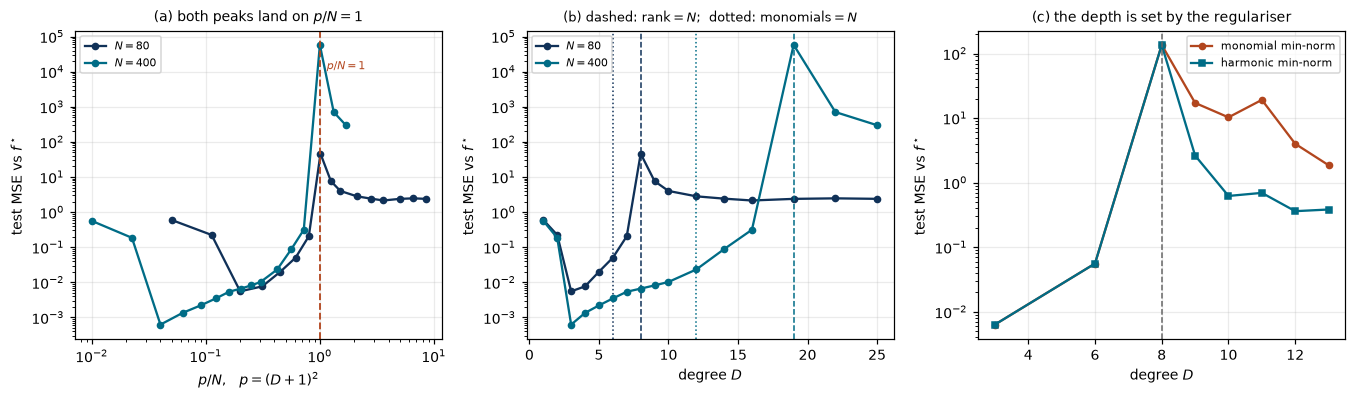

In [50]:
# --- Exercise 12 ----------------------------------------------------------------
# Double descent.  The whole exercise turns on WHICH p is the effective parameter
# count: the monomial count, or the rank (D+1)^2 that section 8.2 measured.
from math import comb


def harmonic_transform_from_gram(G, degree, tol=1e-9):
    """Exercise 10's construction, taking a precomputed Gram so that the same big
    Monte-Carlo sample can be reused for every degree."""
    m = G.shape[0]
    sizes = [comb(d + 2, 2) for d in range(degree + 1)]
    b = np.cumsum([0] + sizes)
    T = np.zeros((m, 0)); blocks = []
    for d in range(degree + 1):
        E = np.zeros((m, sizes[d])); E[b[d]:b[d+1], :] = np.eye(sizes[d])
        if T.shape[1]:
            E = E - T @ (T.T @ G @ E)
        g = E.T @ G @ E
        lam, V = np.linalg.eigh(g)
        keep = lam > tol * max(lam.max(), 1.0)
        T = np.hstack([T, E @ V[:, keep] / np.sqrt(lam[keep])])
        blocks.append(int(keep.sum()))
    return T, blocks


D_MAX_DD = 25
D_GRID = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 19, 22, 25])
N_LIST = [80, 400]
R_DD = 5
N_TE_DD = 4000

mono_count = lambda D: comb(D + 3, 3)
print(f"at D = {D_MAX_DD}: {mono_count(D_MAX_DD)} monomials, but the rank on the sphere")
print(f"is only (D+1)^2 = {(D_MAX_DD+1)**2}.  Those two disagree about where the")
print(f"interpolation threshold should be, so the sweep decides between them:")
for N in N_LIST:
    d_rank = next(D for D in range(60) if (D + 1)**2 >= N)
    d_mono = next(D for D in range(60) if mono_count(D) >= N)
    print(f"    N = {N:4d}: rank says the peak is at D = {d_rank:2d}, "
          f"the monomial count says D = {d_mono:2d}")

X_te_dd = sample_sphere(N_TE_DD, 3, rng)
f_te_dd = f_star(X_te_dd)
Phi_te_full = poly_features(X_te_dd, D_MAX_DD)

dd_test, dd_train = {}, {}
for N in N_LIST:
    te_acc = np.zeros((R_DD, len(D_GRID)))
    tr_acc = np.zeros((R_DD, len(D_GRID)))
    for r in range(R_DD):
        Xtr = sample_sphere(N, 3, rng)
        ytr = f_star(Xtr) + NOISE * rng.normal(size=N)
        Phi_tr_full = poly_features(Xtr, D_MAX_DD)
        for j, D in enumerate(D_GRID):
            m = mono_count(D)
            A, B = Phi_tr_full[:, :m], Phi_te_full[:, :m]
            w, *_ = np.linalg.lstsq(A, ytr, rcond=None)
            tr_acc[r, j] = np.mean((A @ w - ytr) ** 2)
            te_acc[r, j] = np.mean((B @ w - f_te_dd) ** 2)
    dd_test[N] = np.median(te_acc, axis=0)      # median: the peak is wildly heavy-tailed
    dd_train[N] = np.median(tr_acc, axis=0)
    print(f"  N = {N} done")

print(f"\n{'':6s}" + "".join(f"  N={N:<4d}            " for N in N_LIST))
print(f"{'D':>4s} {'p':>6s} {'mono':>6s}" + "  ".join(
    [f"{'p/N':>7s}{'test MSE':>12s}{'train MSE':>11s}" for _ in N_LIST]))
for j, D in enumerate(D_GRID):
    row = f"{D:4d} {(D+1)**2:6d} {mono_count(D):6d}"
    for N in N_LIST:
        row += f"  {(D+1)**2/N:7.2f}{dd_test[N][j]:12.4g}{dd_train[N][j]:11.1e}"
    print(row)

for N in N_LIST:
    j = int(np.argmax(dd_test[N]))
    print(f"\nN = {N}: peak at D = {D_GRID[j]}, i.e. p/N = {(D_GRID[j]+1)**2/N:.2f}, "
          f"test MSE {dd_test[N][j]:.4g}")
    print(f"    best classical degree: D = {D_GRID[int(np.argmin(dd_test[N][:j]))]} "
          f"with {dd_test[N][:j].min():.4g}")
    print(f"    at D = {D_GRID[-1]}: {dd_test[N][-1]:.4g}  "
          f"({dd_test[N][j]/dd_test[N][-1]:.0f}x below the peak, but still "
          f"{dd_test[N][-1]/dd_test[N][:j].min():.0f}x above the classical best)")
print("\n  The peak sits at p/N = 1 for BOTH N, with p = (D+1)^2.  Nothing whatever")
print("  happens where the monomial count equals N.  So the effective parameter count")
print("  is the RANK of the feature map on the sphere -- the geometry of the domain,")
print("  not the algebra of the basis, decides where the model blows up.")
print("  Train MSE past the threshold is ~1e-28: these fits genuinely interpolate,")
print("  so the second descent is not an artefact of a rank-truncated solve.")


# ---- what sets the DEPTH of the second descent? --------------------------------
D_H_MAX = 13          # the numerical harmonic basis stays exact only this far
Ts_dd = {}
G_big = poly_gram(sample_sphere(200000, 3, rng), D_H_MAX)
D_H_GRID = np.array([3, 6, 8, 9, 10, 11, 12, 13])
print(f"\nthe second descent depends on the implicit regulariser (N = 80):")
print(f"{'D':>4s} {'p':>6s} {'monomial min-norm':>19s} {'harmonic min-norm':>19s}")
mono_dd, harm_dd = [], []
Phi_te_H = poly_features(X_te_dd, D_H_MAX)
for D in D_H_GRID:
    m = mono_count(D)
    T_D, blocks = harmonic_transform_from_gram(G_big[:m, :m], D)
    em, eh = [], []
    for r in range(8):
        Xtr = sample_sphere(80, 3, rng)
        ytr = f_star(Xtr) + NOISE * rng.normal(size=80)
        Ptr = poly_features(Xtr, D_H_MAX)[:, :m]
        wm, *_ = np.linalg.lstsq(Ptr, ytr, rcond=None)
        wh, *_ = np.linalg.lstsq(Ptr @ T_D, ytr, rcond=None)
        em.append(np.mean((Phi_te_H[:, :m] @ wm - f_te_dd) ** 2))
        eh.append(np.mean(((Phi_te_H[:, :m] @ T_D) @ wh - f_te_dd) ** 2))
    mono_dd.append(np.median(em)); harm_dd.append(np.median(eh))
    print(f"{D:4d} {(D+1)**2:6d} {mono_dd[-1]:19.4g} {harm_dd[-1]:19.4g}")
print("  Same span, same data, same solver -- only the basis differs, and past the")
print("  threshold the harmonic basis is orders of magnitude better.  'Minimum norm'")
print("  in the harmonic basis is minimum L^2(S^2) norm of the FUNCTION, a smoothness")
print("  penalty; in the monomial basis it is minimum length of an arbitrary")
print("  coordinate vector.  Double descent is real, but how far the error comes back")
print("  down is a property of the implicit regulariser, not of overparametrisation.")
print(f"  (The numerical harmonic basis is only trustworthy to about D = {D_H_MAX}:")
print("   beyond that the monomial Gram is too ill-conditioned for a Monte-Carlo")
print("   estimate to resolve the 2l+1 blocks -- which is why one uses closed-form")
print("   spherical harmonics and recurrences in practice.)")

fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.7))
cols_N = {80: GEO_DARK, 400: GEO_TEAL}

ax = axes[0]
for N in N_LIST:
    ax.loglog((D_GRID + 1)**2 / N, dd_test[N], "o-", color=cols_N[N], ms=4,
              label=f"$N = {N}$")
ax.axvline(1.0, color=GEO_RUST, ls="--", lw=1.2)
ax.text(1.15, dd_test[400].max() * 0.2, r"$p/N=1$", color=GEO_RUST, fontsize=7)
ax.set_xlabel(r"$p/N$,   $p=(D+1)^2$"); ax.set_ylabel(r"test MSE vs $f^\star$")
ax.legend(fontsize=7); ax.set_title("(a) both peaks land on $p/N=1$", fontsize=9)

ax = axes[1]
for N in N_LIST:
    ax.semilogy(D_GRID, dd_test[N], "o-", color=cols_N[N], ms=4, label=f"$N={N}$")
    d_rank = next(D for D in range(60) if (D + 1)**2 >= N)
    d_mono = next(D for D in range(60) if mono_count(D) >= N)
    ax.axvline(d_rank, color=cols_N[N], ls="--", lw=1)
    ax.axvline(d_mono, color=cols_N[N], ls=":", lw=1)
ax.set_xlabel("degree $D$"); ax.set_ylabel(r"test MSE vs $f^\star$")
ax.legend(fontsize=7)
ax.set_title("(b) dashed: rank$=N$;  dotted: monomials$=N$", fontsize=8.5)

ax = axes[2]
ax.semilogy(D_H_GRID, mono_dd, "o-", color=GEO_RUST, ms=4, label="monomial min-norm")
ax.semilogy(D_H_GRID, harm_dd, "s-", color=GEO_TEAL, ms=4, label="harmonic min-norm")
ax.axvline(8, color="0.4", ls="--", lw=1)
ax.set_xlabel("degree $D$"); ax.set_ylabel(r"test MSE vs $f^\star$")
ax.legend(fontsize=7)
ax.set_title("(c) the depth is set by the regulariser", fontsize=9)

plt.tight_layout(); plt.show()


---
## 9. What to take away

- **Sampling is a modelling decision.** "Uniform" means invariant under the
  isometry group; the naive parametrisation is wrong, and the error is invisible
  until you test a statistic whose exact distribution you know. Always have such a
  statistic.
- **Vectorise.** Every distance computation here was a Gram matrix. This is not
  only about speed; array-shaped thinking is how tensors, batches, and
  differentiable programming work from Lecture 3 on.
- **Symmetry is data structure.** $SO(3)$ acts on everything we built. Ignoring it
  wastes capacity; ignoring it *when splitting the data* invalidates the
  experiment.
- **High dimension is not more of the same.** Distances concentrate, random vectors
  are orthogonal, grids are hopeless — and the same concentration is what makes
  empirical risk approximate true risk.
- **The manifold hypothesis is testable.** Global PCA sees the ambient span; local
  PCA sees the tangent space. On a sphere embedded in $\mathbb{R}^{100}$ both give
  the right answer, and you can watch them fail as noise grows.
- **Learning is a variational problem, and the U-curve is real.** We reproduced it
  from first principles, saw the interpolation threshold sitting at $p = N$, and
  tamed it with Tikhonov regularisation — the same regularisation you already know
  from ill-posed inverse problems.

### Next

**Lecture 3** develops the convex, linear-model world where every statement above
can be proved, and **Tutorial 3** applies it to geometric classification and
regression on curves and triangulated surfaces.

### Further reading

- Vershynin, *High-Dimensional Probability* (2018), ch. 3 & 5 — concentration, rigorously; free online.
- Atkinson & Han, *Spherical Harmonics and Approximation on the Unit Sphere* (2012).
- Marques, Bobenko et al. on spherical Delaunay triangulations, for §2.3.
- Lyons, "An elementary introduction to the Hopf fibration", *Math. Mag.* **76** (2003) — the source of the pictures in §5.
- Bronstein, Bruna, Cohen & Veličković, *Geometric Deep Learning* (2021), ch. 3 — symmetry as a design principle; the destination of Exercise 10.